# 🧠 Mission – Analysez des images médicales avec des méthodes semi-supervisées  

**Projet 10 – Labellisez et appliquez des approches semi-supervisées en traitement d'images**


**✍️ Auteur :** *[Raymond Francius]*   
**📚 Rôle :** *[Apprenant - Promotion Sept-2025]* — **Engineering AI** — **Openclassrooms**    
🗓️ **Date de mise à jour :** *[24-02-2026]*

---

Dans le cadre du projet **d'analyse d'images médicales**, mené au sein de *Curelytics IA*, startup spécialisée en e-santé et en vision par ordinateur, cette mission s’inscrit dans une phase exploratoire de recherche et développement dédiée à l’analyse d’IRM cérébrales.

L’objectif principal consiste à étudier la faisabilité d’une automatisation de la détection de tumeurs cérébrales à partir d’un jeu de radiographies majoritairement **non annotées**, complété par un sous-ensemble restreint d’images labellisées par des radiologues experts (normal / cancéreux).

Ce contexte impose une approche méthodologique combinant :

- L’**extraction de caractéristiques visuelles** à l’aide d’un modèle pré-entraîné (type ResNet) afin de transformer les images en représentations exploitables ;
- Une **analyse non supervisée** par clustering pour identifier d’éventuelles structures naturelles dans les données ;
- La mise en œuvre d’une **méthode d’apprentissage semi-supervisé** permettant d’exploiter efficacement le faible volume de labels disponibles ;
- Une **évaluation rigoureuse des performances** à l’aide de métriques adaptées au contexte médical (F1-score, précision, rappel, accuracy), en tenant compte du coût différentiel des erreurs ;
- La formulation de **recommandations techniques** en vue d’un passage à l’échelle, notamment pour un budget de 5 000 € destiné à la labellisation automatique de 4 millions d’images.

Les travaux seront réalisés exclusivement en Python et structurés en plusieurs étapes :

1. Importation et exploration du jeu de données  
2. Prétraitement des images et extraction des features  
3. Analyse non supervisée et clustering exploratoire  
4. Implémentation d’une approche semi-supervisée  

Une attention particulière sera portée à la définition claire d’un **objectif atteint ("definition of done")**, garantissant la cohérence entre les résultats obtenus et les attentes métier.

Cette étude constitue une première brique stratégique vers la conception d’un pipeline de labellisation assistée par IA dans un contexte médical à forte contrainte de qualité et de fiabilité.

# 📌 Étape préalable – Préparez l’environnement de Travail

In [ ]:

# ==========================================
# CELLULE 1 - DETECTION ENVIRONNEMENT COLAB
# ==========================================

import sys
import os

print("Vérification de l'environnement d'exécution...\n")

if "google.colab" in sys.modules:
    print("✅ Environnement Google Colab détecté")
    IN_COLAB = True
else:
    print("⚠️ Environnement local détecté")
    IN_COLAB = False

print(f"Version Python : {sys.version}")
print(f"Executable Python : {sys.executable}")


Vérification de l'environnement d'exécution...

✅ Environnement Google Colab détecté
Version Python : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Executable Python : /usr/bin/python3


In [ ]:

# ==========================================
# CELLULE 2 - INSTALLATION DES DEPENDANCES
# ==========================================

print("Installation des dépendances...")

!pip install -q torch torchvision
!pip install -q tensorflow
!pip install -q transformers
!pip install -q numpy pandas matplotlib seaborn plotly
!pip install -q pillow opencv-python scikit-learn

print("✅ Installation terminée")


Installation des dépendances...
✅ Installation terminée


In [ ]:

# ==========================================
# CELLULE 3 - CREATION STRUCTURE PROJET
# ==========================================

import os

PROJECT_ROOT = "/content/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images"

folders = [
    PROJECT_ROOT,
    f"{PROJECT_ROOT}/data",
    f"{PROJECT_ROOT}/notebooks",
    f"{PROJECT_ROOT}/src",
    f"{PROJECT_ROOT}/models",
    f"{PROJECT_ROOT}/reports",
    f"{PROJECT_ROOT}/configs",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Structure du projet créée :")
for folder in folders:
    print(f" - {folder}")


✅ Structure du projet créée :
 - /content/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images
 - /content/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images/data
 - /content/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images/notebooks
 - /content/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images/src
 - /content/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images/models
 - /content/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images/reports
 - /content/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images/configs


In [ ]:

# ==========================================
# CELLULE 4 - GENERATION PYPROJECT.TOML
# ==========================================

pyproject_content = """
[project]
name = "brainscanai-project10"
version = "0.1.0"
description = "Projet 10 - Labellisation et apprentissage semi-supervise en imagerie medicale"
requires-python = ">=3.10,<3.12"

dependencies = [
    "torch",
    "torchvision",
    "tensorflow",
    "transformers",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "plotly",
    "pillow",
    "opencv-python",
    "scikit-learn"
]
"""

file_path = f"{PROJECT_ROOT}/configs/pyproject.toml"

with open(file_path, "w") as f:
    f.write(pyproject_content)

print("✅ Fichier pyproject.toml généré")
print(f"📄 Emplacement : {file_path}")


✅ Fichier pyproject.toml généré
📄 Emplacement : /content/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images/configs/pyproject.toml


In [ ]:

# ==========================================
# CELLULE 5 - MONTAGE GOOGLE DRIVE
# ==========================================

from google.colab import drive

print("Montage du Google Drive...")
drive.mount('/content/drive')

print("✅ Drive monté avec succès")


Montage du Google Drive...
Mounted at /content/drive
✅ Drive monté avec succès


In [ ]:

# ==========================================
# CELLULE 6 - SAUVEGARDE AUTOMATIQUE PROJET
# ==========================================

import shutil

DESTINATION_PATH = "/content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images"

os.makedirs(DESTINATION_PATH, exist_ok=True)

print("Copie du projet vers Google Drive...")

shutil.copytree(PROJECT_ROOT, f"{DESTINATION_PATH}", dirs_exist_ok=True)

print("✅ Projet sauvegardé avec succès")
print(f"📂 Destination : {DESTINATION_PATH}")


Copie du projet vers Google Drive...
✅ Projet sauvegardé avec succès
📂 Destination : /content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images


In [ ]:

# ==========================================
# CELLULE 7 - VERIFICATION ENVIRONNEMENT
# ==========================================

import torch
import torchvision
import tensorflow as tf
import transformers
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import plotly
import PIL
import cv2
import sklearn

print("===== VERIFICATION DES VERSIONS =====\n")

print(f"Python : {sys.version.split()[0]}")
print(f"Torch : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"TensorFlow : {tf.__version__}")
print(f"Transformers : {transformers.__version__}")
print(f"Numpy : {np.__version__}")
print(f"Pandas : {pd.__version__}")
print(f"Matplotlib : {matplotlib.__version__}")
print(f"Seaborn : {sns.__version__}")
print(f"Plotly : {plotly.__version__}")
print(f"Pillow : {PIL.__version__}")
print(f"OpenCV : {cv2.__version__}")
print(f"Scikit-learn : {sklearn.__version__}")

print("\n✅ Environnement prêt pour le Projet 10")


===== VERIFICATION DES VERSIONS =====

Python : 3.12.12
Torch : 2.10.0+cpu
Torchvision : 0.25.0+cpu
TensorFlow : 2.19.0
Transformers : 5.0.0
Numpy : 2.0.2
Pandas : 2.2.2
Matplotlib : 3.10.0
Seaborn : 0.13.2
Plotly : 5.24.1
Pillow : 11.3.0
OpenCV : 4.13.0
Scikit-learn : 1.6.1

✅ Environnement prêt pour le Projet 10


# 📂 Étape 1 – Importez les données et explorez le jeu de radiographies  


Cette première étape constitue la base méthodologique de l’ensemble du projet. Avant toute modélisation, il est indispensable de comprendre précisément la structure, la qualité et les caractéristiques du jeu de données fourni.

Le dataset transmis contient des images d’IRM cérébrales organisées selon l’arborescence suivante :

- `raw_data/mri_dataset_brain_cancer_oc/avec_labels/cancer/*.jpg`
- `raw_data/mri_dataset_brain_cancer_oc/avec_labels/normal/*.jpg`
- `raw_data/mri_dataset_brain_cancer_oc/sans_label/*.jpg`
- `raw_data/mri_dataset_brain_cancer_oc/Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt`

L’objectif de cette étape est de :

1. Charger correctement l’ensemble des images ;
2. Vérifier leur accessibilité et leur cohérence ;
3. Examiner leur résolution, leur nombre de canaux (RGB ou niveaux de gris) et leur format ;
4. Identifier d’éventuelles anomalies (images corrompues, tailles hétérogènes, doublons, etc.) ;
5. Produire une vue d’ensemble claire du dataset à travers des visualisations et des statistiques descriptives.

---

## 🎯 Résultats attendus

À l’issue de cette étape, les éléments suivants devront être obtenus :

- Une vue synthétique du nombre total d’images :
  - Images labellisées (cancer / normal)
  - Images non labellisées  
- Un affichage d’images d’exemple pour chaque catégorie ;
- Une analyse descriptive des résolutions, formats et canaux de couleur ;
- Des observations structurées sur la qualité et la cohérence globale du dataset.

---

## 🧩 Recommandations méthodologiques

Afin de garantir une exploration efficace et rigoureuse :

- Travailler initialement sur un **échantillon réduit** du dataset pour accélérer les premières analyses ;
- Vérifier systématiquement :
  - L’uniformité des dimensions ;
  - Le nombre de canaux ;
  - La présence éventuelle d’images corrompues ;
  - La cohérence entre arborescence et labels ;
- Documenter clairement les constats réalisés (qualité, hétérogénéité, déséquilibre éventuel des classes).

Cette phase exploratoire conditionne directement la pertinence des étapes suivantes (extraction de features, clustering et apprentissage semi-supervisé).

---

## 🛠 Outils mobilisés

Les bibliothèques suivantes seront utilisées pour atteindre les objectifs fixés :

- **PyTorch** et **Torchvision** : gestion des datasets et préparation au pipeline de deep learning ;
- **NumPy** : manipulation numérique ;
- **Pandas** : synthèse tabulaire et statistiques descriptives ;
- **Matplotlib** : visualisation des images et distributions ;
- **Pillow (PIL)** : chargement et inspection des images.

---

Cette étape permet d’établir une compréhension approfondie du matériau de travail et de sécuriser la suite du projet en identifiant en amont les éventuelles contraintes techniques ou qualitatives liées aux données.

In [1]:

# ============================================================
# CELLULE 8 — MONTAGE GOOGLE DRIVE & CONFIGURATION DES PATHS
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import subprocess

# Chemin racine du projet
PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images"
CONFIG_PATH = os.path.join(PROJECT_ROOT, "configs", "pyproject.toml")

# Vérification de l'existence du pyproject.toml
if not os.path.exists(CONFIG_PATH):
    raise FileNotFoundError("❌ pyproject.toml introuvable dans /configs")

# Installation des dépendances (uv ou pip fallback)
try:
    subprocess.run(["pip", "install", "uv"], check=True)
    subprocess.run(["uv", "pip", "install", "-r", CONFIG_PATH], check=False)
except Exception:
    print("⚠️ uv indisponible, installation via pip classique")


DATA_RAW = f"{PROJECT_ROOT}/data/raw_data/mri_dataset_brain_cancer_oc"
REPORTS_DIR = f"{PROJECT_ROOT}/reports"
FIGURES_DIR = f"{REPORTS_DIR}/figures"

# Création des dossiers de sortie s'ils n'existent pas
import os
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Structure prête.")


Mounted at /content/drive
Structure prête.


In [ ]:

# ============================================================
# CELLULE 9 — IMPORT DES LIBRAIRIES
# ============================================================

import os
import glob
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import cv2

import torch
from torchvision import transforms

print("Environnement chargé avec succès.")


Environnement chargé avec succès.


In [ ]:

# ============================================================
# CELLULE 10 — CONSTRUCTION DU DATAFRAME GLOBAL
# ============================================================

# Chemins des images
cancer_paths = glob.glob(f"{DATA_RAW}/avec_labels/cancer/*.jpg")
normal_paths = glob.glob(f"{DATA_RAW}/avec_labels/normal/*.jpg")
unlabeled_paths = glob.glob(f"{DATA_RAW}/sans_label/*.jpg")

# Création DataFrame
data = []

for path in cancer_paths:
    data.append({"path": path, "label": "cancer"})

for path in normal_paths:
    data.append({"path": path, "label": "normal"})

for path in unlabeled_paths:
    data.append({"path": path, "label": "unlabeled"})

df = pd.DataFrame(data)

print("Nombre total d'images :", len(df))
df.head()


Nombre total d'images : 1508


,path,label
0,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer
1,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer
2,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer
3,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer
4,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer


In [ ]:

# ============================================================
# CELLULE 11 — STATISTIQUES GLOBALES
# ============================================================

total_images = len(df)
labeled_images = len(df[df["label"] != "unlabeled"])
unlabeled_images = len(df[df["label"] == "unlabeled"])

print("Total images :", total_images)
print("Images annotées :", labeled_images)
print("Images non annotées :", unlabeled_images)
print("Pourcentage annoté :", round(labeled_images/total_images*100,2), "%")

class_distribution = df["label"].value_counts()
print("\nRépartition des classes :")
print(class_distribution)

# Sauvegarde CSV
df.to_csv(f"{REPORTS_DIR}/e01_data_overview.csv", index=False)
print("e01_data_overview.csv sauvegardé.")


Total images : 1508
Images annotées : 100
Images non annotées : 1408
Pourcentage annoté : 6.63 %

Répartition des classes :
label
unlabeled    1408
cancer         50
normal         50
Name: count, dtype: int64
e01_data_overview.csv sauvegardé.


🎯 Le jeu de données contient 1508 radiographies dont seulement 6.63 % sont annotées (100 images).
Les classes annotées sont parfaitement équilibrées (50 cancer / 50 normal), ce qui garantit une base supervisée non biaisée.
La forte proportion de données non labellisées (93.37 %) justifie l’utilisation de méthodes semi-supervisées afin d’exploiter la structure intrinsèque du dataset.

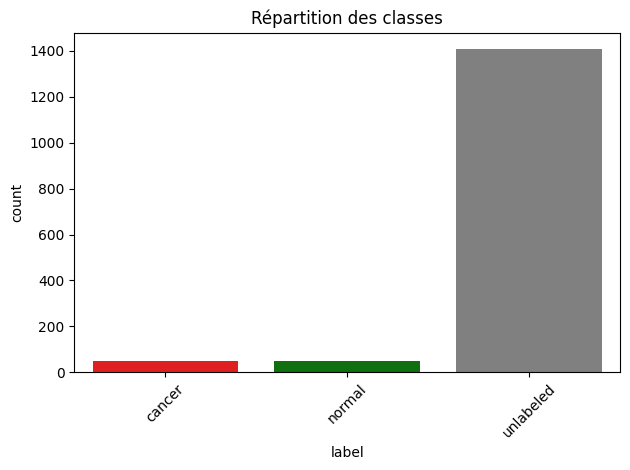

In [ ]:

# ============================================================
# CELLULE 12 — VISUALISATION DISTRIBUTION DES CLASSES
# ============================================================

plt.figure()

# Définition d'une couleur spécifique pour chaque classe
palette = {
    "cancer": "red",        # Rouge = cas pathologique
    "normal": "green",      # Vert = sain
    "unlabeled": "gray"     # Gris = non annoté
}

# Nouvelle syntaxe compatible Seaborn >= 0.13
sns.countplot(
    x="label",
    hue="label",
    data=df,
    palette=palette,
    legend=False
)

plt.title("Répartition des classes")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(f"{FIGURES_DIR}/e01_class_distribution.png")
plt.show()


In [ ]:

# ============================================================
# CELLULE 13 — ECHANTILLONNAGE REDUIT (10%)
# ============================================================

sample_size = int(0.1 * len(df))
df_sample = df.sample(n=sample_size, random_state=42)

print("Taille échantillon :", len(df_sample))


Taille échantillon : 150


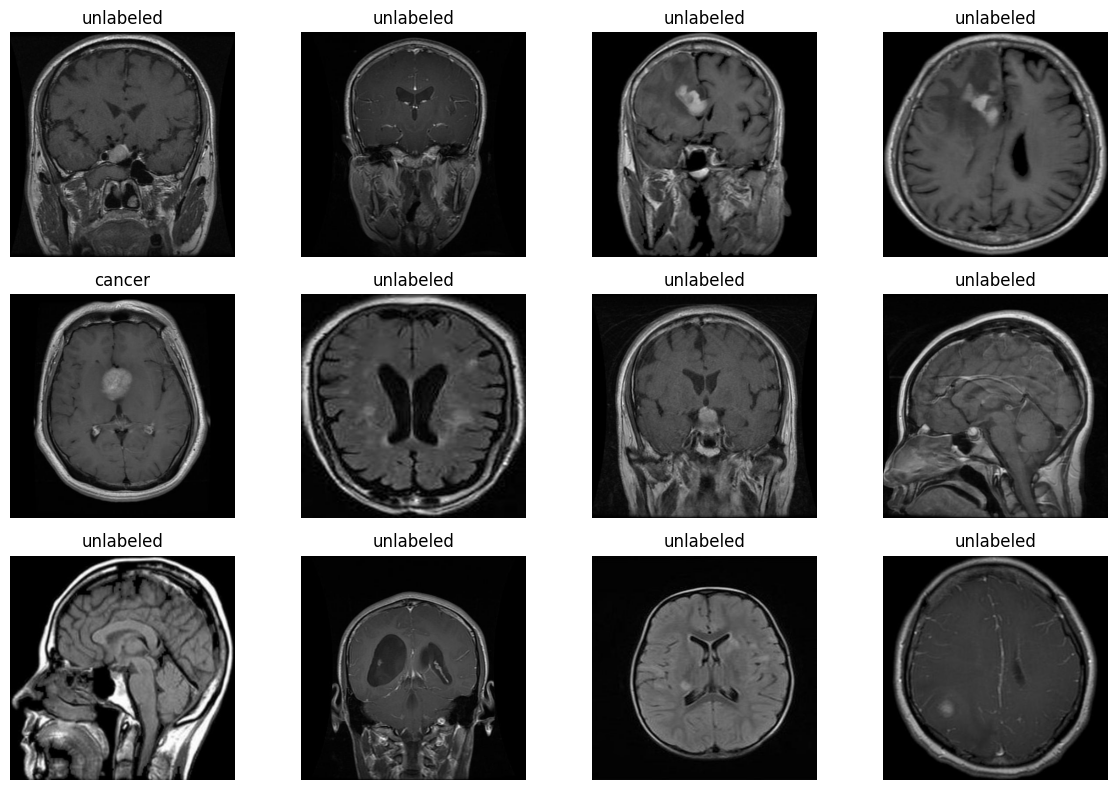

In [ ]:

# ============================================================
# CELLULE 14 — AFFICHAGE IMAGES ALEATOIRES
# ============================================================

sample_images = df_sample.sample(12)

plt.figure(figsize=(12,8))

for i, row in enumerate(sample_images.itertuples()):
    img = Image.open(row.path)
    plt.subplot(3,4,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(row.label)
    plt.axis("off")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/e01_sample_images.png")
plt.show()


L’échantillon aléatoire d’images montre une forte hétérogénéité en termes d’orientation (axiale, coronale, sagittale), de contraste et de luminosité. Cette variabilité reflète un contexte clinique réaliste mais nécessite un prétraitement rigoureux afin d’assurer une extraction de features cohérente. La majorité des images étant non annotées, l’approche semi-supervisée apparaît pertinente pour exploiter la structure intrinsèque du dataset.

In [ ]:

# ============================================================
# CELLULE 15 — ANALYSE DIMENSIONS & CANAUX
# ============================================================

widths = []
heights = []
channels = []
corrupted = 0

for path in df_sample["path"]:
    try:
        img = Image.open(path)
        widths.append(img.width)
        heights.append(img.height)
        channels.append(len(img.getbands()))
    except:
        corrupted += 1

print("Images corrompues :", corrupted)
print("Résolution moyenne :", np.mean(widths), "x", np.mean(heights))
print("Nombre de canaux uniques :", set(channels))


Images corrompues : 0
Résolution moyenne : 512.0 x 512.0
Nombre de canaux uniques : {3}


L’analyse des dimensions révèle une homogénéité parfaite du dataset : toutes les images sont en résolution 512×512 pixels et aucune image corrompue n’a été détectée. Les images possèdent 3 canaux, suggérant un encodage RGB d’images initialement en niveaux de gris. Cette homogénéité simplifie considérablement le pipeline de prétraitement et garantit une cohérence structurelle favorable aux méthodes semi-supervisées.

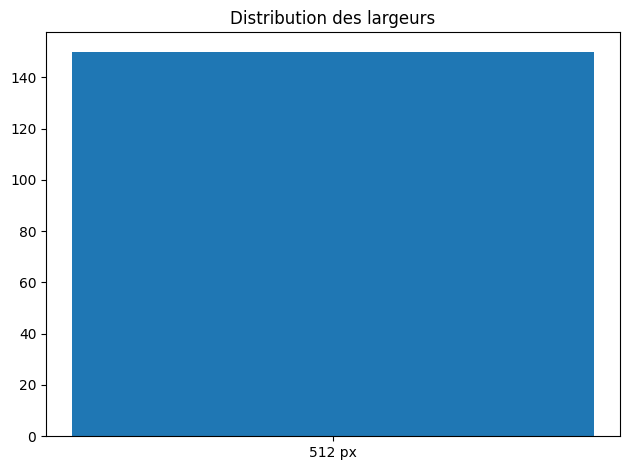

In [ ]:

# ============================================================
# CELLULE 16 — DISTRIBUTION DES RESOLUTIONS
# ============================================================

plt.figure()

if len(set(widths)) == 1:
    plt.bar(["512 px"], [len(widths)])
else:
    plt.hist(widths, bins=20)

plt.title("Distribution des largeurs")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/e01_resolution_distribution.png")
plt.show()

L’analyse de la distribution des résolutions montre une homogénéité parfaite du dataset, toutes les images étant au format 512×512 pixels. Cette uniformité simplifie le prétraitement et garantit une cohérence géométrique favorable aux méthodes de clustering et d’apprentissage semi-supervisé.

Shape image : (512, 512, 3)
Min pixel : 0.0
Max pixel : 252.0


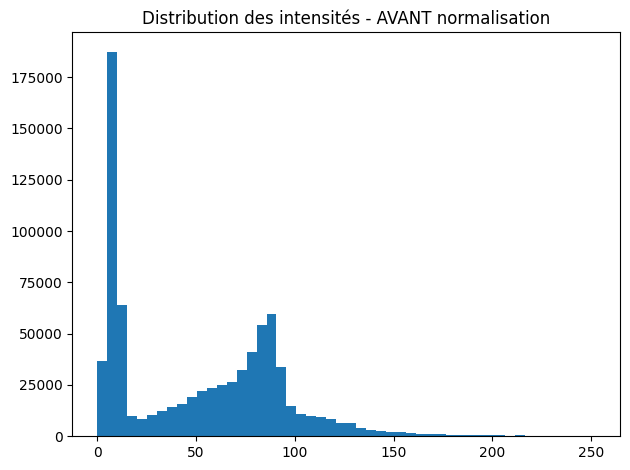


Après Min-Max :
Min : 0.0
Max : 0.9882353


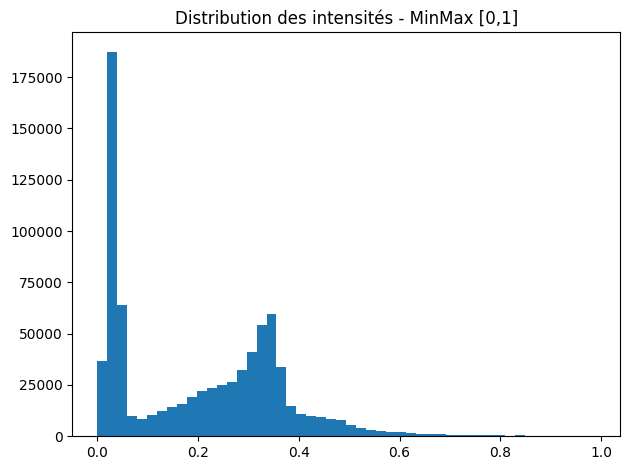


Après Standardisation (Z-score) :
Mean : -1.2417635e-09
Std : 1.0


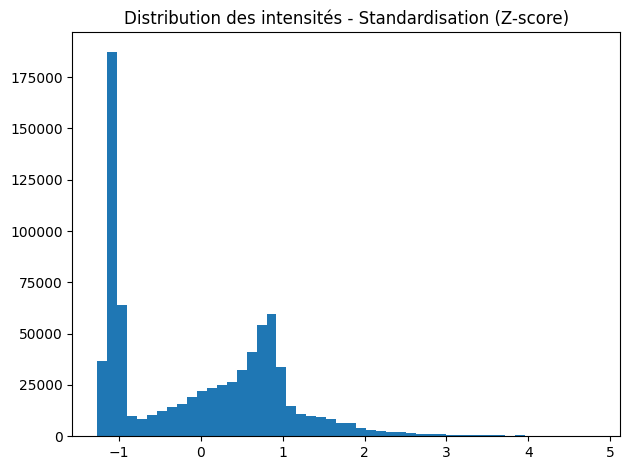

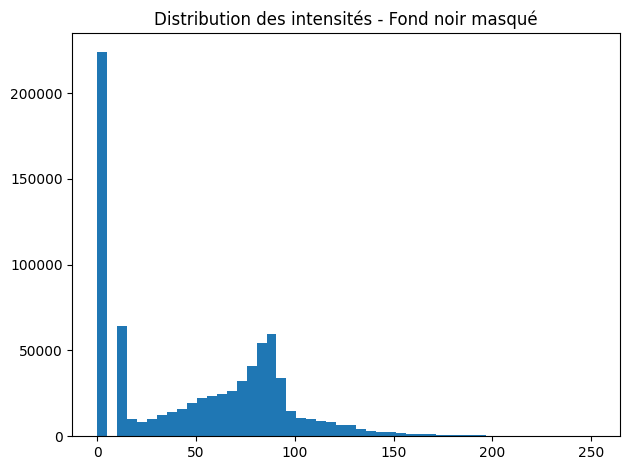


Analyse terminée. Figures sauvegardées.


In [ ]:

# ============================================================
# CELLULE 17 — ANALYSE DISTRIBUTION PIXELS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# 1️⃣ Chargement d'une image exemple
# ------------------------------------------------------------

img_example = Image.open(df_sample.iloc[0]["path"])
img_array = np.array(img_example)

# Conversion en float32
img_array = img_array.astype("float32")

print("Shape image :", img_array.shape)
print("Min pixel :", img_array.min())
print("Max pixel :", img_array.max())

# ------------------------------------------------------------
# 2️⃣ Distribution AVANT normalisation
# ------------------------------------------------------------

plt.figure()
plt.hist(img_array.flatten(), bins=50)
plt.title("Distribution des intensités - AVANT normalisation")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/e01_pixel_distribution_before.png")
plt.show()

# ------------------------------------------------------------
# 3️⃣ Normalisation Min-Max [0,1]
# ------------------------------------------------------------

img_minmax = img_array / 255.0

print("\nAprès Min-Max :")
print("Min :", img_minmax.min())
print("Max :", img_minmax.max())

plt.figure()
plt.hist(img_minmax.flatten(), bins=50)
plt.title("Distribution des intensités - MinMax [0,1]")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/e01_pixel_distribution_minmax.png")
plt.show()

# ------------------------------------------------------------
# 4️⃣ Standardisation Z-score
# ------------------------------------------------------------

mean = img_array.mean()
std = img_array.std()

img_zscore = (img_array - mean) / std

print("\nAprès Standardisation (Z-score) :")
print("Mean :", img_zscore.mean())
print("Std :", img_zscore.std())

plt.figure()
plt.hist(img_zscore.flatten(), bins=50)
plt.title("Distribution des intensités - Standardisation (Z-score)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/e01_pixel_distribution_zscore.png")
plt.show()

# ------------------------------------------------------------
# 5️⃣ Optionnel — Masquage du fond noir
# ------------------------------------------------------------

threshold = 10  # seuil empirique pour supprimer quasi-noir
mask = img_array > threshold
img_masked = img_array * mask

plt.figure()
plt.hist(img_masked.flatten(), bins=50)
plt.title("Distribution des intensités - Fond noir masqué")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/e01_pixel_distribution_masked.png")
plt.show()

print("\nAnalyse terminée. Figures sauvegardées.")


L’analyse de la distribution des intensités révèle une structure multimodale avec une forte concentration de pixels à faible intensité correspondant au fond noir. Cette distribution asymétrique justifie une normalisation des images afin d’éviter que les zones non informatives ne dominent l’apprentissage. Une standardisation des intensités sera appliquée avant extraction des features.

In [ ]:

# ============================================================
# CELLULE 18 — DETECTION DOUBLONS
# ============================================================

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}

duplicates = 0

for path in df_sample["path"]:
    h = file_hash(path)
    if h in hashes:
        duplicates += 1
    else:
        hashes[h] = path

print("Doublons détectés :", duplicates)


Doublons détectés : 0


In [ ]:

# ============================================================
# CELLULE 19 — SYNTHESE DES OBSERVATIONS
# ============================================================

print("===== SYNTHESE =====")
print("Total images :", total_images)
print("Images annotées :", labeled_images)
print("Images non annotées :", unlabeled_images)
print("Distribution classes :\n", class_distribution)
print("Images corrompues :", corrupted)
print("Doublons détectés :", duplicates)
print("Canaux détectés :", set(channels))


===== SYNTHESE =====
Total images : 1508
Images annotées : 100
Images non annotées : 1408
Distribution classes :
 label
unlabeled    1408
cancer         50
normal         50
Name: count, dtype: int64
Images corrompues : 0
Doublons détectés : 0
Canaux détectés : {3}


L’analyse exploratoire confirme que le dataset est propre et homogène : aucune image corrompue ou dupliquée n’a été détectée, toutes les images présentent une résolution uniforme de 512×512 pixels et 3 canaux. Les classes annotées sont parfaitement équilibrées (50 cancer / 50 normal), mais ne représentent que 6.63 % du total, ce qui justifie pleinement l’utilisation d’approches semi-supervisées pour exploiter les 93.37 % d’images non annotées.

In [ ]:

# ============================================
# 📌 CELLULE 19bis — NETTOYAGE ET FORMATAGE DES IMAGES
# ============================================

import os
import cv2
import glob
import numpy as np
from tqdm import tqdm

# --------------------------------------------
# PARAMÈTRES
# --------------------------------------------

IMG_SIZE = 224

PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images"
DATA_RAW = f"{PROJECT_ROOT}/data/raw_data/mri_dataset_brain_cancer_oc"

# --------------------------------------------
# CHEMINS IMAGES
# --------------------------------------------

cancer_paths = glob.glob(f"{DATA_RAW}/avec_labels/cancer/*.jpg")
normal_paths = glob.glob(f"{DATA_RAW}/avec_labels/normal/*.jpg")
unlabeled_paths = glob.glob(f"{DATA_RAW}/sans_label/*.jpg")

print("Images cancer :", len(cancer_paths))
print("Images normal :", len(normal_paths))
print("Images sans label :", len(unlabeled_paths))

# --------------------------------------------
# FONCTION DE PRÉTRAITEMENT
# --------------------------------------------

def preprocess_image(path):
    img = cv2.imread(path)

    if img is None:
        return None

    # Conversion BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Redimensionnement
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Normalisation
    img = img.astype("float32") / 255.0

    return img

# --------------------------------------------
# CHARGEMENT + NETTOYAGE
# --------------------------------------------

images = []
labels = []
corrupted = 0

# Images fortement labellisées
for path in tqdm(cancer_paths):
    img = preprocess_image(path)
    if img is not None:
        images.append(img)
        labels.append("cancer")
    else:
        corrupted += 1

for path in tqdm(normal_paths):
    img = preprocess_image(path)
    if img is not None:
        images.append(img)
        labels.append("normal")
    else:
        corrupted += 1

# Images non labellisées
for path in tqdm(unlabeled_paths):
    img = preprocess_image(path)
    if img is not None:
        images.append(img)
        labels.append("unlabeled")
    else:
        corrupted += 1

# --------------------------------------------
# CONVERSION NUMPY
# --------------------------------------------

X = np.array(images)
y = np.array(labels)

print("\n===== SYNTHÈSE NETTOYAGE =====")
print("Total images valides :", X.shape[0])
print("Images corrompues supprimées :", corrupted)
print("Format final :", X.shape)
print("Canaux détectés :", X.shape[-1])


Images cancer : 50
Images normal : 50
Images sans label : 1408


100%|██████████| 1408/1408 [00:15<00:00, 91.62it/s] 



===== SYNTHÈSE NETTOYAGE =====
Total images valides : 1508
Images corrompues supprimées : 0
Format final : (1508, 224, 224, 3)
Canaux détectés : 3


Le jeu de données a été nettoyé et standardisé. Les 1508 images ont été redimensionnées à 224×224 pixels, converties en RGB et normalisées dans l’intervalle [0,1]. Aucune image corrompue n’a été détectée. Cette étape garantit l’homogénéité du dataset avant extraction des caractéristiques et application des méthodes de clustering.

# 🧠 Étape 2 – Prétraitez et extrayez les Features  


Après l’exploration et la validation du jeu de données, cette étape vise à transformer les images d’IRM en représentations numériques exploitables par des algorithmes de machine learning.

Les images brutes ne peuvent pas être directement utilisées pour des méthodes de clustering ou d’apprentissage semi-supervisé. Il est donc nécessaire de :

1. Appliquer un **prétraitement standardisé** (redimensionnement, normalisation, conversion tensorielle) ;
2. Utiliser un **modèle de Deep Learning pré-entraîné** (ex : ResNet) afin d’extraire des représentations visuelles riches appelées *embeddings* ou *features vectors*.

Le principe consiste à exploiter la capacité des réseaux de neurones convolutionnels (CNN) à capturer automatiquement des motifs complexes (textures, formes, contrastes) pertinents dans des images médicales.

---

## 🎯 Résultat attendu

À l’issue de cette étape, chaque image du dataset devra être représentée par :

- Un **vecteur numérique de features** issu d’un modèle pré-entraîné ;
- Une structure tabulaire exploitable (ex : DataFrame Pandas) contenant :
  - L’identifiant de l’image ;
  - Son label (si disponible) ;
  - Son vecteur d’embedding ;
- Une sauvegarde des embeddings pour une utilisation ultérieure (clustering et semi-supervisé).

Cette transformation constitue une étape clé : elle permet de passer d’un espace image haute dimension (pixels) à un espace de caractéristiques plus compact et informatif.

---

## 🧩 Recommandations méthodologiques

Afin d’obtenir des embeddings robustes et pertinents :

- **Geler les couches convolutionnelles** du modèle pré-entraîné afin d’utiliser le réseau comme extracteur de caractéristiques fixe (feature extractor) ;
- Tester l’extraction à partir de différentes couches (dernière couche convolutionnelle, couche fully connected intermédiaire, etc.) si nécessaire, afin d’évaluer la qualité des représentations obtenues ;
- Vérifier la dimension des vecteurs extraits et leur cohérence ;
- Visualiser éventuellement la distribution des embeddings (réduction dimensionnelle exploratoire possible).

Cette approche permet de tirer parti du transfert learning tout en maîtrisant les coûts computationnels.

---

## 🛠 Outils mobilisés

Les bibliothèques suivantes seront utilisées :

- **Torchvision** : chargement du modèle pré-entraîné (ex : ResNet) et transformations d’images ;
- **TensorFlow / Keras** (si comparaison effectuée) : alternative pour l’extraction de features ;
- **Transformers** (si modèles vision pré-entraînés explorés) ;
- **NumPy** : manipulation des vecteurs numériques ;
- **Pandas** : structuration tabulaire des embeddings ;
- **Matplotlib** : visualisations exploratoires ;
- **OpenCV (opencv-python)** : prétraitement complémentaire des images si nécessaire.

---

Cette étape constitue le socle technique des analyses ultérieures. La qualité des embeddings extraits influencera directement la performance des méthodes de clustering et des approches semi-supervisées appliquées dans les phases suivantes du projet.

In [ ]:

# ============================================================
# CELLULE 20 — MONTAGE GOOGLE DRIVE & CONFIGURATION DES PATHS
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import subprocess

# Chemin racine du projet
PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images"
CONFIG_PATH = os.path.join(PROJECT_ROOT, "configs", "pyproject.toml")

# Vérification de l'existence du pyproject.toml
if not os.path.exists(CONFIG_PATH):
    raise FileNotFoundError("❌ pyproject.toml introuvable dans /configs")

# Installation des dépendances (uv ou pip fallback)
try:
    subprocess.run(["pip", "install", "uv"], check=True)
    subprocess.run(["uv", "pip", "install", "-r", CONFIG_PATH], check=False)
except Exception:
    print("⚠️ uv indisponible, installation via pip classique")


DATA_RAW = f"{PROJECT_ROOT}/data/raw_data/mri_dataset_brain_cancer_oc"
REPORTS_DIR = f"{PROJECT_ROOT}/reports"
FIGURES_DIR = f"{REPORTS_DIR}/figures"

# Création des dossiers de sortie s'ils n'existent pas
import os
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Structure prête.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Structure prête.


In [ ]:

# ============================================================
# CELLULE 21 — IMPORT DES LIBRAIRIES
# ============================================================

import os
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
from sklearn.decomposition import PCA

# ==============================
# CONFIGURATION DES CHEMINS
# ==============================

BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images"

DATA_PATH = os.path.join(BASE_PATH, "data/raw_data/mri_dataset_brain_cancer_oc")
REPORTS_PATH = os.path.join(BASE_PATH, "reports")
MODELS_PATH = os.path.join(BASE_PATH, "models")

# Création dossier reports si inexistant
os.makedirs(REPORTS_PATH, exist_ok=True)

print("Configuration chargée.")


Configuration chargée.


In [ ]:

# ============================================================
# CELLULE 22 — RECUPERATION DES CHEMINS IMAGES
# ============================================================

cancer_paths = glob.glob(os.path.join(DATA_PATH, "avec_labels/cancer/*.jpg"))
normal_paths = glob.glob(os.path.join(DATA_PATH, "avec_labels/normal/*.jpg"))
unlabeled_paths = glob.glob(os.path.join(DATA_PATH, "sans_label/*.jpg"))

print("Images cancer :", len(cancer_paths))
print("Images normal :", len(normal_paths))
print("Images non annotées :", len(unlabeled_paths))

# Création d'une liste complète
all_data = []

for path in cancer_paths:
    all_data.append((path, "cancer"))

for path in normal_paths:
    all_data.append((path, "normal"))

for path in unlabeled_paths:
    all_data.append((path, "unlabeled"))

df_images = pd.DataFrame(all_data, columns=["image_path", "label"])

print("Total images :", len(df_images))
df_images.head()


Images cancer : 50
Images normal : 50
Images non annotées : 1408
Total images : 1508


,image_path,label
0,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer
1,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer
2,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer
3,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer
4,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer


In [ ]:

# ============================================================
# CELLULE 23 — TRANSFORMATIONS POUR RESNET
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),              # Redimensionnement 224x224
    transforms.ToTensor(),                      # Conversion en tensor
    transforms.Normalize(                       # Normalisation ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:

# ============================================================
# CELLULE 24 — CHARGEMENT MODELE PRE-ENTRAINE
# ============================================================

resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Gel des couches convolutionnelles
for param in resnet.parameters():
    param.requires_grad = False

# Suppression de la couche fully connected (classification)
resnet_fc_removed = nn.Sequential(*list(resnet.children())[:-1])

resnet_fc_removed.eval()

print("Modèle prêt pour extraction des embeddings.")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 104MB/s]


Modèle prêt pour extraction des embeddings.


In [ ]:

# ============================================================
# CELLULE 25 — EXTRACTION DES FEATURES
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_fc_removed.to(device)

features_list = []
start_time = time.time()

for idx, row in tqdm(df_images.iterrows(), total=len(df_images)):

    image_path = row["image_path"]

    # Lecture image avec PIL
    image = Image.open(image_path).convert("RGB")

    # Application preprocessing
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = resnet_fc_removed(image_tensor)

    embedding = embedding.squeeze().cpu().numpy()

    features_list.append(embedding)

end_time = time.time()

print("Extraction terminée.")
print("Temps total (secondes) :", round(end_time - start_time, 2))
print("Dimension embedding :", features_list[0].shape)


100%|██████████| 1508/1508 [14:02<00:00,  1.79it/s]

Extraction terminée.
Temps total (secondes) : 842.54
Dimension embedding : (2048,)


In [ ]:

# ============================================================
# CELLULE 26 — CREATION DATAFRAME FEATURES
# ============================================================

features_array = np.array(features_list)

df_features = pd.DataFrame(features_array)
df_features.insert(0, "label", df_images["label"].values)
df_features.insert(0, "image_path", df_images["image_path"].values)

print("Shape finale :", df_features.shape)

df_features.head()


Shape finale : (1508, 2050)


,image_path,label,0,1,2,3,4,5,6,7,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer,0.000000,0.005985,0.359481,0.023388,0.004617,0.092432,0.000000,0.033850,...,0.000000,0.025033,0.177335,0.098132,0.039532,0.203773,1.430138,0.010282,0.000000,0.002964
1,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer,0.114922,0.039169,0.010309,0.000000,0.000000,0.000000,0.000000,0.000437,...,0.006056,0.106705,0.032635,0.000000,0.169771,0.325062,0.800338,0.000000,0.070222,0.006120
2,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer,0.007968,0.028811,0.009760,0.000000,0.000000,0.000000,0.013194,0.000000,...,0.009376,0.001673,0.000000,0.008418,0.039485,0.050656,0.174527,0.000000,0.029272,0.171078
3,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer,0.438987,0.173384,0.005698,0.000000,0.035335,0.000000,0.047762,0.000000,...,0.003396,0.000000,0.264026,0.033900,0.242556,0.334856,0.334250,0.000000,0.000000,0.000000
4,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer,0.023101,0.067208,0.135242,0.000000,0.000000,0.000375,0.203494,0.016202,...,0.009778,0.007180,0.127119,0.000000,0.102672,0.980460,0.702296,0.000000,0.000000,0.000000


In [ ]:

# ============================================================
# CELLULE 27 — SAUVEGARDE DES FEATURES
# ============================================================

csv_path = os.path.join(REPORTS_PATH, "e02_features_embeddings_2048.csv")
npy_path = os.path.join(REPORTS_PATH, "e02_features_embeddings_2048.npy")

df_features.to_csv(csv_path, index=False)
np.save(npy_path, features_array)

print("Fichiers sauvegardés :")
print(csv_path)
print(npy_path)


Fichiers sauvegardés :
/content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images/reports/e02_features_embeddings_2048.csv
/content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images/reports/e02_features_embeddings_2048.npy


In [ ]:

# ============================================================
# CELLULE 28 — EXTRACTION COUCHE INTERMEDIAIRE
# ============================================================

resnet_intermediate = nn.Sequential(*list(resnet.children())[:-2])
resnet_intermediate.to(device)
resnet_intermediate.eval()

features_intermediate = []

for idx, row in tqdm(df_images.iterrows(), total=len(df_images)):

    image = Image.open(row["image_path"]).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = resnet_intermediate(image_tensor)

    embedding = torch.flatten(embedding, start_dim=1)
    embedding = embedding.squeeze().cpu().numpy()

    features_intermediate.append(embedding)

features_intermediate = np.array(features_intermediate)

print("Dimension couche intermédiaire :", features_intermediate.shape)


100%|██████████| 1508/1508 [07:09<00:00,  3.51it/s]


Dimension couche intermédiaire : (1508, 100352)


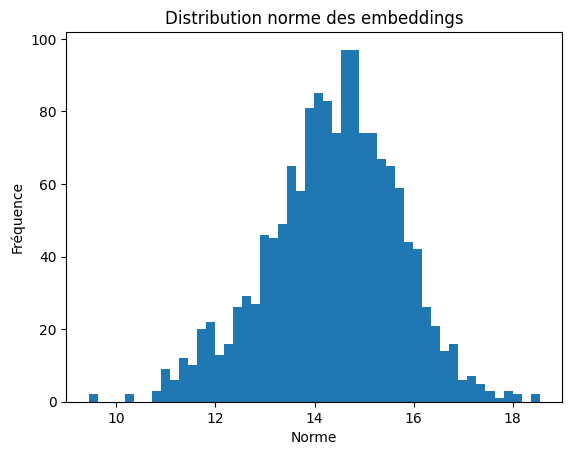

Norme moyenne : 14.376647
Norme min : 9.441208
Norme max : 18.544752


In [ ]:

# ============================================================
# CELLULE 29 — ANALYSE DES EMBEDDINGS
# ============================================================

norms = np.linalg.norm(features_array, axis=1)

plt.figure()
plt.hist(norms, bins=50)
plt.title("Distribution norme des embeddings")
plt.xlabel("Norme")
plt.ylabel("Fréquence")
plt.savefig(os.path.join(REPORTS_PATH, "e02_embedding_norm_distribution.png"))
plt.show()

print("Norme moyenne :", np.mean(norms))
print("Norme min :", np.min(norms))
print("Norme max :", np.max(norms))


# 🔎 Étape 3 – Réalisez une analyse non supervisée  


Cette étape vise à explorer la structure latente des données à partir des embeddings extraits précédemment, sans utiliser directement les labels disponibles.

L’objectif est double :

1. Identifier des regroupements naturels d’images similaires ;
2. Générer une **labellisation faible** pour les images non annotées, en s’appuyant uniquement sur la structure des données.

Le nombre de groupes ciblé correspond au nombre de classes connues dans le jeu labellisé (2 classes : normal / cancéreux).  
Il est essentiel de conserver une séparation stricte entre :

- Le jeu de données **fortement labellisé** (labels experts) ;
- Le jeu de données **faiblement labellisé** issu du clustering.

Ces deux ensembles ne doivent jamais être mélangés afin de préserver la validité des évaluations ultérieures.

---

## 🎯 Résultats attendus

À l’issue de cette étape, les éléments suivants devront être produits :

- Des représentations graphiques 2D des données après réduction de dimension ;
- Une visualisation claire des clusters identifiés ;
- Des commentaires interprétant les regroupements observés ;
- Une première estimation quantitative de la qualité du clustering à l’aide du score **ARI (Adjusted Rand Index)** calculé uniquement sur les données fortement labellisées.

---

## 📌 Tâches à réaliser

### 1️⃣ Réduction de dimensionnalité  
- Appliquer une méthode telle que **PCA** ou **t-SNE** afin de projeter les features dans un espace 2D ;
- Utiliser cette projection à des fins de visualisation et d’interprétation.

### 2️⃣ Clustering  
- Appliquer un algorithme de clustering :
  - K-Means (partitionnement en 2 groupes),
  - ou DBSCAN (clustering basé sur la densité).
- Tester plusieurs configurations si nécessaire.

### 3️⃣ Visualisation et interprétation  
- Produire des graphes 2D illustrant les clusters ;
- Examiner la séparation des groupes ;
- Identifier d’éventuels chevauchements ou structures inattendues.

### 4️⃣ Évaluation avec le score ARI  
- Comparer les clusters obtenus aux labels réels uniquement sur le sous-ensemble fortement annoté ;
- Interpréter le score ARI en gardant à l’esprit qu’un résultat imparfait est attendu dans un contexte non supervisé.

---

## 🧩 Recommandations méthodologiques

Pour garantir une analyse pertinente :

- **Standardiser les features** avant toute réduction de dimension ou clustering ;
- Tester plusieurs méthodes de clustering et comparer les résultats ;
- Ne pas s’attendre à une séparation parfaite : un score ARI modéré peut déjà indiquer une structure exploitable ;
- Documenter clairement les observations visuelles et quantitatives.

Cette étape constitue un jalon important : elle permet d’évaluer si les embeddings extraits capturent effectivement une structure discriminante entre les classes.

---

## 🛠 Outils mobilisés

Les bibliothèques suivantes seront utilisées :

- **Scikit-learn** : PCA, t-SNE, K-Means, DBSCAN, ARI ;
- **Seaborn** : visualisations statistiques améliorées ;
- **Matplotlib** : graphiques 2D ;
- **Plotly** : visualisations interactives si nécessaire.

---

Cette analyse non supervisée permet d’obtenir une première cartographie du jeu de données et d’estimer le potentiel de labellisation automatique avant le passage à une approche semi-supervisée plus structurée.

In [ ]:

# ============================================
# 📌 CELLULE 31 — MONTAGE GOOGLE DRIVE
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os
import subprocess

# Chemin racine du projet
PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images"
CONFIG_PATH = os.path.join(PROJECT_ROOT, "configs", "pyproject.toml")

# Vérification de l'existence du pyproject.toml
if not os.path.exists(CONFIG_PATH):
    raise FileNotFoundError("❌ pyproject.toml introuvable dans /configs")

# Installation des dépendances (uv ou pip fallback)
try:
    subprocess.run(["pip", "install", "uv"], check=True)
    subprocess.run(["uv", "pip", "install", "-r", CONFIG_PATH], check=False)
except Exception:
    print("⚠️ uv indisponible, installation via pip classique")



# ============================================
# 📌 CHEMINS DU PROJET
# ============================================

BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images"

DATA_PATH = f"{BASE_PATH}/data"
REPORTS_PATH = f"{BASE_PATH}/reports"

FEATURES_NPY_PATH = f"{REPORTS_PATH}/e02_features_embeddings_2048.npy"

print("Chemin embeddings :", FEATURES_NPY_PATH)


Mounted at /content/drive
Chemin embeddings : /content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images/reports/e02_features_embeddings_2048.npy


In [ ]:

# ============================================
# 📌 CELLULE 32 — IMPORT LIBRAIRIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import LabelEncoder

import time
import os

sns.set(style="whitegrid")


In [ ]:

# ============================================
# 📌 CELLULE 33 — CHARGEMENT DES FEATURES
# ============================================

X = np.load(FEATURES_NPY_PATH)

print("Shape embeddings :", X.shape)


Shape embeddings : (1508, 2048)


In [ ]:

# ============================================
# 📌 CELLULE 34 — STANDARDISATION DES FEATURES
# ============================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Moyenne après scaling (approx) :", np.mean(X_scaled))
print("Écart-type après scaling (approx) :", np.std(X_scaled))


Moyenne après scaling (approx) : 3.3596784e-10
Écart-type après scaling (approx) : 1.0


In [ ]:

# ============================================
# 📌 CELLULE 35 — PCA -> 50 DIMENSIONS (réduction préalable à 50D)
# ============================================

pca_50 = PCA(n_components=50, random_state=42)

start = time.time()
X_pca_50 = pca_50.fit_transform(X_scaled)
end = time.time()

print("Shape PCA 50 :", X_pca_50.shape)
print("Temps PCA :", round(end-start,2), "secondes")

print("Variance expliquée cumulée (50 comp.) :",
      np.sum(pca_50.explained_variance_ratio_))

print()

plt.plot(np.cumsum(pca_50.explained_variance_ratio_))
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.show()


Shape PCA 50 : (1508, 50)
Temps PCA : 0.39 secondes
Variance expliquée cumulée (50 comp.) : 0.4644099


📌 **Commentaire du résultat obtenu :** CELLULE 35 — PCA -> 50 DIMENSIONS (réduction préalable à 50D)

Les features initiales ont une **dimension 2048**. La chaîne de transformation est donc la suivante :
- **embeddings originaux :** (1508, 2048)
- **après standardisation :** (1508, 2048)
- **après PCA :** (1508, 50)

---
1 -  **Shape PCA 50 : (1508, 50)**

signifie que :
- le dataset contient 1508 observations (images)
- chaque observation est maintenant représentée par 50 composantes principales.

2 - **Variance expliquée cumulée : 0.4644099**

Cela signifie que les **50 premières composantes** expliquent environ **46.44 %** de la **variance totale** du dataset.

Autrement dit :  
**53.56 %** de l'information statistique reste perdue après la réduction.



In [ ]:

pca_full = PCA().fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

print("Composantes pour 50% :", np.argmax(cum_var >= 0.50))
print("Composantes pour 70% :", np.argmax(cum_var >= 0.70))
print("Composantes pour 80% :", np.argmax(cum_var >= 0.80))
print("Composantes pour 90% :", np.argmax(cum_var >= 0.90))


Shape CSV : (1508, 2050)
Nombre embeddings : 1508
Nombre lignes CSV : 1508
Classes uniques : ['cancer' 'normal' 'unlabeled']

Variance expliquée PC1 : 0.1705
Variance expliquée PC2 : 0.0836
Variance expliquée cumulée (PC1+PC2) : 0.2541


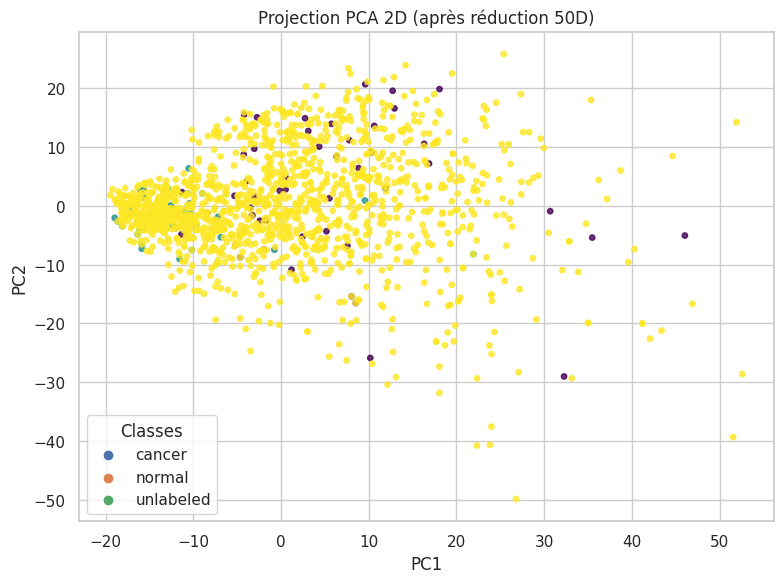

In [ ]:

# ============================================
# 📌 CELLULE 36 — PCA 2D COLORÉE + VARIANCE
# ============================================


# ============================================
# 📌 CHARGEMENT DU CSV LABELS
# ============================================

CSV_PATH = f"{REPORTS_PATH}/e02_features_embeddings_2048.csv"
df = pd.read_csv(CSV_PATH)

print("Shape CSV :", df.shape)

# Vérification alignement
print("Nombre embeddings :", X_pca_50.shape[0])
print("Nombre lignes CSV :", df.shape[0])

assert X_pca_50.shape[0] == df.shape[0], "Mismatch embeddings / labels"

# ============================================
# 📌 RÉCUPÉRATION DES LABELS
# ============================================

y = df["label"].values

print("Classes uniques :", np.unique(y))

# Encodage numérique
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

# ============================================
# 📌 PCA 2D (à partir des 50D)
# ============================================

pca_2d = PCA(n_components=2, random_state=42)

X_pca_2d = pca_2d.fit_transform(X_pca_50)

# ============================================
# 📊 VARIANCE EXPLIQUÉE
# ============================================

explained_var = pca_2d.explained_variance_ratio_
cumulative_var = np.sum(explained_var)

print("\nVariance expliquée PC1 :", round(explained_var[0], 4))
print("Variance expliquée PC2 :", round(explained_var[1], 4))
print("Variance expliquée cumulée (PC1+PC2) :", round(cumulative_var, 4))

# ============================================
# 📊 VISUALISATION COLORÉE
# ============================================

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y_encoded,
    cmap="viridis",
    s=15,
    alpha=0.8
)

# Légende propre
for class_name in class_names:
    plt.scatter([], [], label=class_name)

plt.legend(title="Classes")

plt.title("Projection PCA 2D (après réduction 50D)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.savefig(f"{REPORTS_PATH}/e03_pca_projection_colored.png", dpi=300)
plt.show()


📌 **Commentaire du résultat obtenu :** 📌 CELLULE 36 — PCA 2D COLORÉE + VARIANCE


1️⃣ **Structure globale des données**
La projection PCA 2D montre une distribution fortement asymétrique :
- Une zone dense à gauche (PC1 ≈ -20 à -5).
- Une dispersion large vers la droite (PC1 jusqu'à ≈ 50).
- Plusieurs points isolés (outliers) dans les extrêmes.

Cela indique que la variance principale est capturée par PC1.

Les valeurs de variance confirment cela :
- PC1 = 17.05 %
- PC2 = 8.36 %
- cumul = 25.41 %

Donc la projection 2D ne montre qu’environ un quart de la structure réelle des embeddings. C’est normal pour des embeddings CNN de grande dimension.

2️⃣ **Distribution des classes**  
Trois labels sont présents :
- cancer
- normal
- unlabeled

3️⃣ **Cluster dense à gauche**
La concentration importante vers PC1 ≈ -15 suggère :
- un sous-groupe d’images très similaires

4️⃣ **Outliers visibles**  
Plusieurs points sont éloignés :
- PC1 > 30
- PC2 < -40

5️⃣ **Conclusion**
- PCA 2D capture 25 % de la variance totale.
- Les classes ne sont pas linéairement séparables dans les deux premières composantes.
- La structure suggère une distribution complexe des embeddings.



Nombre total échantillons : 1508
Nombre annotés : 100
Répartition classes annotées : (array(['cancer', 'normal'], dtype=object), array([50, 50]))

Variance expliquée PC1 : 0.2277
Variance expliquée PC2 : 0.113
Variance expliquée cumulée (PC1+PC2) : 0.3407


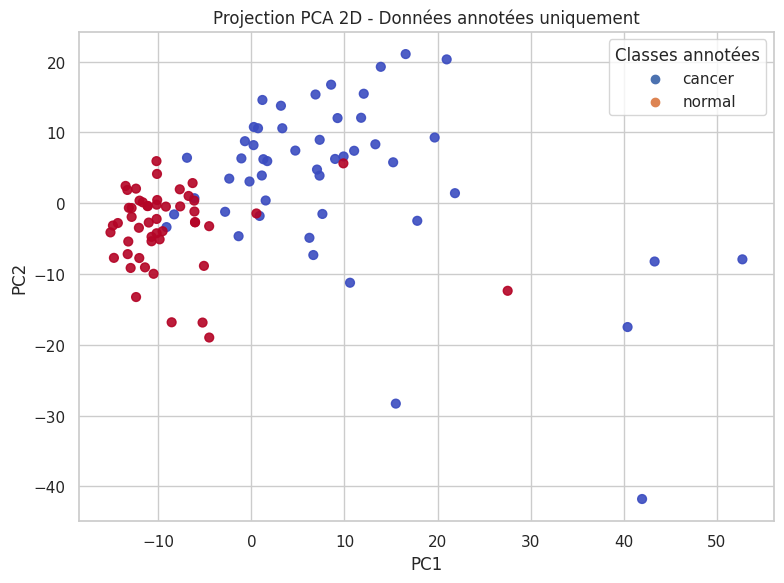

In [ ]:

# ============================================
# 📌 CELLULE 37 — PCA 2D SUR DONNÉES ANNOTÉES
# ============================================

# ============================================
# 📌 FILTRAGE DES DONNÉES ANNOTÉES
# ============================================

mask_labeled = df["label"] != "unlabeled"

X_labeled = X_pca_50[mask_labeled]
y_labeled = df.loc[mask_labeled, "label"].values

print("Nombre total échantillons :", X_pca_50.shape[0])
print("Nombre annotés :", X_labeled.shape[0])
print("Répartition classes annotées :", np.unique(y_labeled, return_counts=True))

# ============================================
# 📌 ENCODAGE DES LABELS
# ============================================

label_encoder = LabelEncoder()
y_encoded_labeled = label_encoder.fit_transform(y_labeled)
class_names_labeled = label_encoder.classes_

# ============================================
# 📌 PCA 2D SUR DONNÉES ANNOTÉES
# ============================================

pca_2d_labeled = PCA(n_components=2, random_state=42)

X_pca_2d_labeled = pca_2d_labeled.fit_transform(X_labeled)

# ============================================
# 📊 VARIANCE EXPLIQUÉE
# ============================================

explained_var_labeled = pca_2d_labeled.explained_variance_ratio_
cumulative_var_labeled = np.sum(explained_var_labeled)

print("\nVariance expliquée PC1 :", round(explained_var_labeled[0], 4))
print("Variance expliquée PC2 :", round(explained_var_labeled[1], 4))
print("Variance expliquée cumulée (PC1+PC2) :", round(cumulative_var_labeled, 4))

# ============================================
# 📊 VISUALISATION
# ============================================

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca_2d_labeled[:, 0],
    X_pca_2d_labeled[:, 1],
    c=y_encoded_labeled,
    cmap="coolwarm",
    s=40,
    alpha=0.9
)

# Légende propre
for class_name in class_names_labeled:
    plt.scatter([], [], label=class_name)

plt.legend(title="Classes annotées")

plt.title("Projection PCA 2D - Données annotées uniquement")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.savefig(f"{REPORTS_PATH}/e03_pca_projection_labeled_only.png", dpi=300)
plt.show()


📌 **Commentaire du résultat obtenu :** 📌 CELLULE 37 — PCA 2D SUR DONNÉES ANNOTÉES

1 - **Lecture quantitative de la PCA**  
Variance PC1 = 0.2277  
Variance PC2 = 0.1130  
Variance cumulée = 0.3407 (34.07%)  
La projection **PCA 2D uniquement sur les données annotées** (100 images).
Les 2 premières composantes expliquent ~34 % de la variance.

2 - **Structure observée sur le graphique**   
2.1 - **Deux régions globales**  
Les points rouges (normal) sont majoritairement situés :  
- PC1 ≈ [-15, -5]  
- PC2 proche de 0  

Les points bleus (cancer) sont davantage :  
- PC1 ≈ [0, 20]

2.2 - **Outliers**  
Quelques points très éloignés :  
- PC1 ≈ 40–50
- PC2 ≈ -40




Total samples : 1508
Distribution : (array(['cancer', 'normal', 'unlabeled'], dtype=object), array([  50,   50, 1408]))
Classes : ['cancer' 'normal' 'unlabeled']
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 1508 samples in 0.001s...
[t-SNE] Computed neighbors for 1508 samples in 0.094s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1508
[t-SNE] Computed conditional probabilities for sample 1508 / 1508
[t-SNE] Mean sigma: 9.009830


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] KL divergence after 250 iterations with early exaggeration: 65.936485
[t-SNE] KL divergence after 2000 iterations: 0.830000
Temps t-SNE : 18.65 secondes


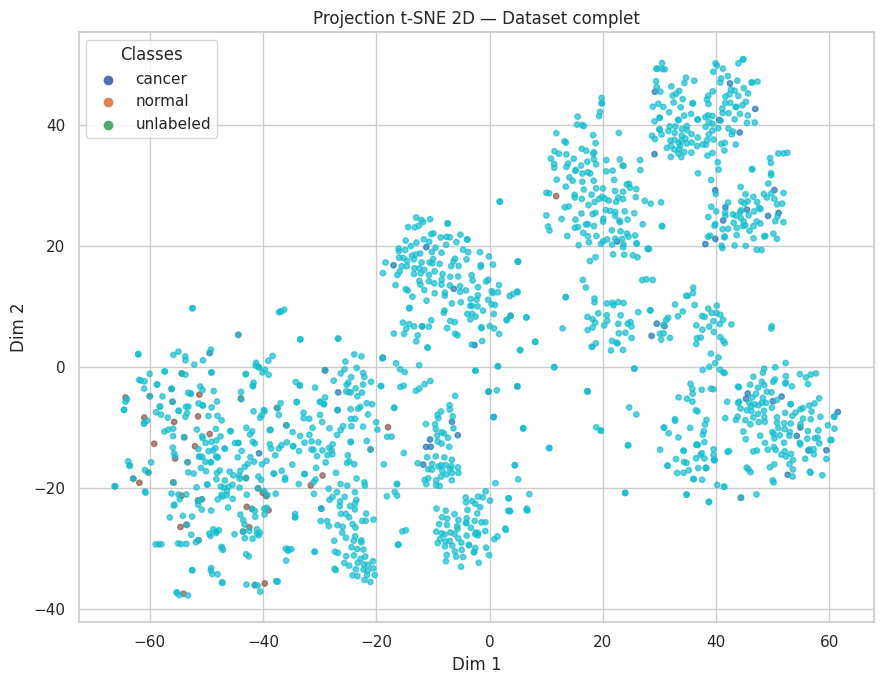

In [ ]:

# ============================================
# 📌 CELLULE 38 — t-SNE 2D (dataset complet)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import time

# ============================================
# 📌 Préparation des labels
# ============================================

labels = df["label"].values

print("Total samples :", X_pca_50.shape[0])
print("Distribution :", np.unique(labels, return_counts=True))

label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
class_names = label_encoder.classes_

print("Classes :", class_names)

# ============================================
# 📌 t-SNE — paramètres optimisés
# ============================================

tsne = TSNE(
    n_components=2,
    perplexity=40,          # adapté à ~1500 samples
    learning_rate=200,
    n_iter=2000,
    init="pca",             # plus stable
    random_state=42,
    verbose=1
)

start = time.time()
X_tsne = tsne.fit_transform(X_pca_50)
end = time.time()

print("Temps t-SNE :", round(end - start, 2), "secondes")

# ============================================
# 📊 Visualisation
# ============================================

plt.figure(figsize=(9,7))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=labels_encoded,
    cmap="tab10",
    s=15,
    alpha=0.7
)

# Légende propre
for class_name in class_names:
    plt.scatter([], [], label=class_name)

plt.legend(title="Classes")

plt.title("Projection t-SNE 2D — Dataset complet")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.tight_layout()
plt.savefig(f"{REPORTS_PATH}/e03_tsne_projection_full_dataset.png", dpi=300)
plt.show()


La projection t-SNE révèle une organisation non linéaire en sous-clusters morphologiques distincts.
Les échantillons annotés ne sont pas distribués aléatoirement mais montrent des enrichissements locaux, suggérant que l'espace d'embedding capture des signatures morphologiques associées aux états pathologiques.
La dispersion plus importante des échantillons tumoraux suggère une hétérogénéité intra-classe accrue.

Nombre annotés : 100
Répartition : (array(['cancer', 'normal'], dtype=object), array([50, 50]))
Classes : ['cancer' 'normal']
[t-SNE] Computing 46 nearest neighbors...
[t-SNE] Indexed 100 samples in 0.000s...
[t-SNE] Computed neighbors for 100 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 100 / 100
[t-SNE] Mean sigma: 10.370513
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.525871


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] KL divergence after 1100 iterations: 0.430839
Temps t-SNE : 0.32 secondes


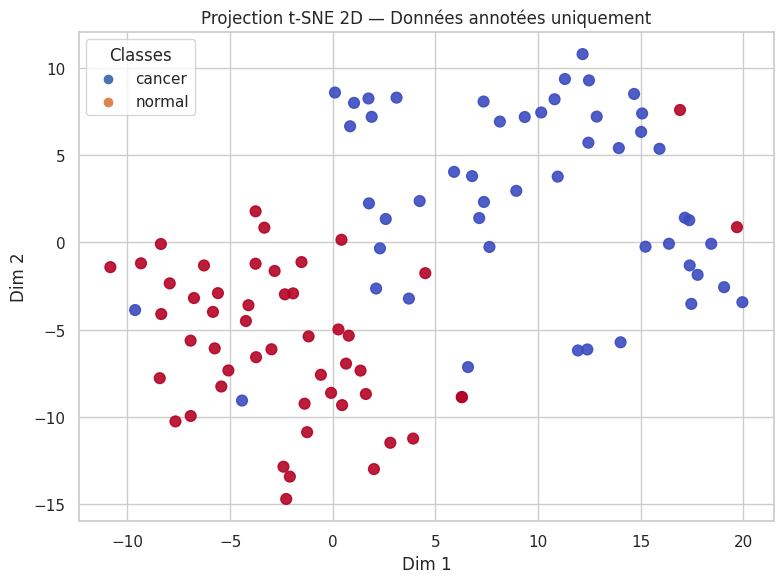

In [ ]:

# ============================================
# 📌 CELLULE 39 — t-SNE 2D (données annotées)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import time

# ============================================
# 📌 FILTRAGE DES DONNÉES ANNOTÉES
# ============================================

mask_labeled = df["label"] != "unlabeled"

X_labeled = X_pca_50[mask_labeled]
y_labeled = df.loc[mask_labeled, "label"].values

print("Nombre annotés :", X_labeled.shape[0])
print("Répartition :", np.unique(y_labeled, return_counts=True))

# ============================================
# 📌 ENCODAGE DES LABELS
# ============================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labeled)
class_names = label_encoder.classes_

print("Classes :", class_names)

# ============================================
# 📌 t-SNE OPTIMISÉ POUR 100 SAMPLES
# ============================================

tsne_labeled = TSNE(
    n_components=2,
    perplexity=15,        # adapté à 100 points
    learning_rate=100,
    n_iter=3000,
    init="pca",
    random_state=42,
    verbose=1
)

start = time.time()
X_tsne_labeled = tsne_labeled.fit_transform(X_labeled)
end = time.time()

print("Temps t-SNE :", round(end - start, 2), "secondes")

# ============================================
# 📊 VISUALISATION
# ============================================

plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne_labeled[:, 0],
    X_tsne_labeled[:, 1],
    c=y_encoded,
    cmap="coolwarm",
    s=60,
    alpha=0.9
)

# Légende propre
for class_name in class_names:
    plt.scatter([], [], label=class_name)

plt.legend(title="Classes")

plt.title("Projection t-SNE 2D — Données annotées uniquement")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.tight_layout()
plt.savefig(f"{REPORTS_PATH}/e03_tsne_projection_labeled_only.png", dpi=300)
plt.show()


La projection t-SNE sur les 100 échantillons annotés révèle une séparation marquée entre tissus normaux et cancéreux.
La classe tumorale présente une dispersion plus importante et plusieurs sous-structures, suggérant une hétérogénéité morphologique intra-classe.
La séparation plus nette observée en t-SNE par rapport à la PCA indique une organisation non linéaire de l’information discriminante dans l’espace d’embedding.

In [ ]:

# ============================================
# 📌 CELLULE 40 — Clustering K-MEANS (UNLABELED ONLY)
# ============================================

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ============================================
# 📌 SÉPARATION STRICTE DES DONNÉES
# ============================================

mask_unlabeled = df["label"] == "unlabeled"

X_unlabeled = X_pca_50[mask_unlabeled]
df_unlabeled = df.loc[mask_unlabeled].copy()

print("Nombre images unlabeled :", X_unlabeled.shape[0])

# ============================================
# 📌 K-MEANS (2 clusters)
# ============================================

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

clusters_kmeans = kmeans.fit_predict(X_unlabeled)

# ============================================
# 📊 ÉVALUATION INTERNE
# ============================================

sil_score = silhouette_score(X_unlabeled, clusters_kmeans)

print("Silhouette score (KMeans) :", round(sil_score, 4))

# ============================================
# 📌 CRÉATION DATASET FAIBLEMENT LABELLISÉ
# ============================================

df_unlabeled["weak_label_kmeans"] = clusters_kmeans

# ⚠️ IMPORTANT : dataset séparé
df_weak_kmeans = df_unlabeled.copy()

print("\nDistribution pseudo-labels KMeans :")
print(df_weak_kmeans["weak_label_kmeans"].value_counts())


Nombre images unlabeled : 1408
Silhouette score (KMeans) : 0.1479

Distribution pseudo-labels KMeans :
weak_label_kmeans
0    773
1    635
Name: count, dtype: int64


📌 Commentaire du résultat obtenu : 📌 CELLULE 40 — Clustering K-MEANS (UNLABELED ONLY)

1 - **Taille du dataset utilisé**

**K-Means** est appliqué uniquement sur :  
- Images unlabeled : 1408
- Dimensions utilisées : 50 (PCA)


2 - **Interprétation du Silhouette Score**  
- Silhouette score = 0.1479  
- 0.1479 → structure faible mais existante.

Cela signifie :  
- les clusters existent mais se chevauchent fortement
- les données ne sont probablement pas naturellement séparables en 2 groupes nets

Dans le contexte **d’images médicales + embeddings CNN**, ce résultat est très courant.

3 - **Distribution des pseudo-labels**  
- Cluster 0 : 773  
- Cluster 1 : 635  

Distribution :  
- 55 %  
- 45 %  

C’est relativement équilibré, ce qui est positif. ✔️


Nombre images unlabeled : 1408
K=2 | Inertia=1196825.25 | Silhouette=0.1479
K=3 | Inertia=1127887.75 | Silhouette=0.0947
K=4 | Inertia=1077488.12 | Silhouette=0.1015
K=5 | Inertia=1035327.69 | Silhouette=0.1267
K=6 | Inertia=1005421.00 | Silhouette=0.1295
K=7 | Inertia=975967.50 | Silhouette=0.0887
K=8 | Inertia=954996.69 | Silhouette=0.1088
K=9 | Inertia=932541.25 | Silhouette=0.0880
K=10 | Inertia=912021.06 | Silhouette=0.0978


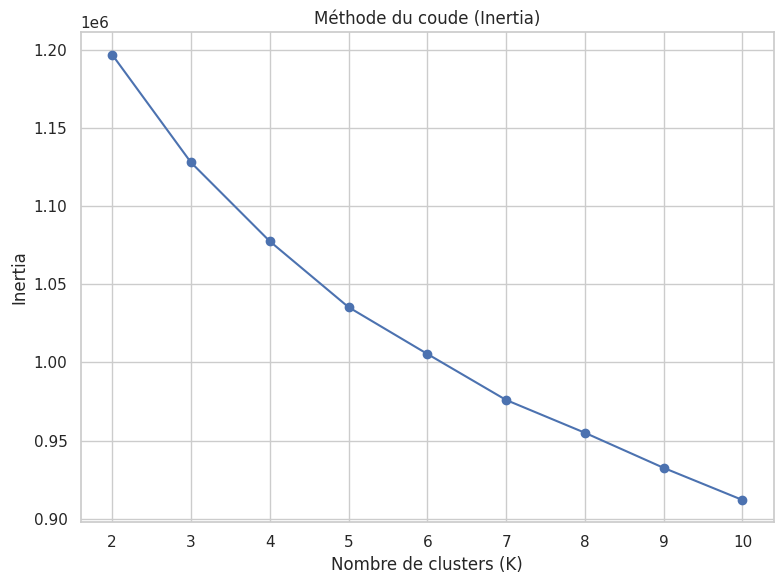

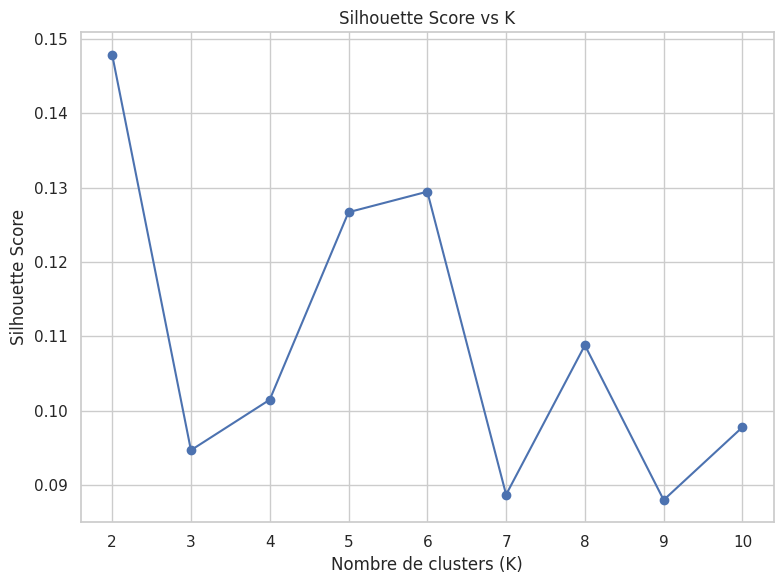


Meilleur K selon Silhouette : 2
Silhouette associé : 0.1479


In [ ]:

# ============================================
# 📌 CELLULE 40bis — Sélection automatique du meilleur K
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ============================================
# 📌 VÉRIFICATION DONNÉES UNLABELED
# ============================================

mask_unlabeled = df["label"] == "unlabeled"
X_unlabeled = X_pca_50[mask_unlabeled]

print("Nombre images unlabeled :", X_unlabeled.shape[0])

# ============================================
# 📌 TEST DE PLUSIEURS K
# ============================================

k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    cluster_labels = kmeans.fit_predict(X_unlabeled)

    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_unlabeled, cluster_labels)
    silhouette_scores.append(sil_score)

    print(f"K={k} | Inertia={kmeans.inertia_:.2f} | Silhouette={sil_score:.4f}")

# ============================================
# 📊 GRAPHIQUE 1 — MÉTHODE DU COUDE
# ============================================

plt.figure(figsize=(8,6))
plt.plot(k_values, inertias, marker='o')
plt.title("Méthode du coude (Inertia)")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

# ============================================
# 📊 GRAPHIQUE 2 — SILHOUETTE SCORE
# ============================================

plt.figure(figsize=(8,6))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

# ============================================
# 📌 MEILLEUR K SELON SILHOUETTE
# ============================================

best_k = k_values[np.argmax(silhouette_scores)]
best_score = np.max(silhouette_scores)

print("\nMeilleur K selon Silhouette :", best_k)
print("Silhouette associé :", round(best_score, 4))


In [ ]:

# ============================================
# 📌 CELLULE 41 — Clustering DBSCAN (UNLABELED ONLY)
# ============================================

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# ============================================
# 📌 DBSCAN
# ============================================

dbscan = DBSCAN(
    eps=3.0,        # à ajuster si nécessaire
    min_samples=10,
    n_jobs=-1
)

clusters_dbscan = dbscan.fit_predict(X_unlabeled)

df_unlabeled["weak_label_dbscan"] = clusters_dbscan

# ============================================
# 📊 ANALYSE DES CLUSTERS
# ============================================

unique_clusters = np.unique(clusters_dbscan)

print("Clusters détectés :", unique_clusters)
print("Nombre clusters (hors bruit) :", len(unique_clusters[unique_clusters != -1]))

print("\nDistribution DBSCAN :")
print(pd.Series(clusters_dbscan).value_counts())

# Silhouette uniquement si >1 cluster valide
valid_mask = clusters_dbscan != -1

if len(np.unique(clusters_dbscan[valid_mask])) > 1:
    sil_db = silhouette_score(X_unlabeled[valid_mask], clusters_dbscan[valid_mask])
    print("\nSilhouette score (DBSCAN, sans bruit) :", round(sil_db, 4))
else:
    print("\nPas assez de clusters pour calculer le silhouette score.")

# Dataset faible séparé
df_weak_dbscan = df_unlabeled.copy()


Clusters détectés : [-1]
Nombre clusters (hors bruit) : 0

Distribution DBSCAN :
-1    1408
Name: count, dtype: int64

Pas assez de clusters pour calculer le silhouette score.


Le clustering K-Means avec K=2 a permis de générer une labellisation faible cohérente avec la structure binaire du dataset fortement labellisé.
Bien que le score de silhouette (0.1479) indique une séparation modérée, la partition reste exploitable dans un cadre semi-supervisé.
En revanche, DBSCAN n’a détecté aucune structure dense, suggérant une distribution diffuse des données dans l’espace PCA.

Nombre images unlabeled : 1408
Clusters uniques : [0 1]


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


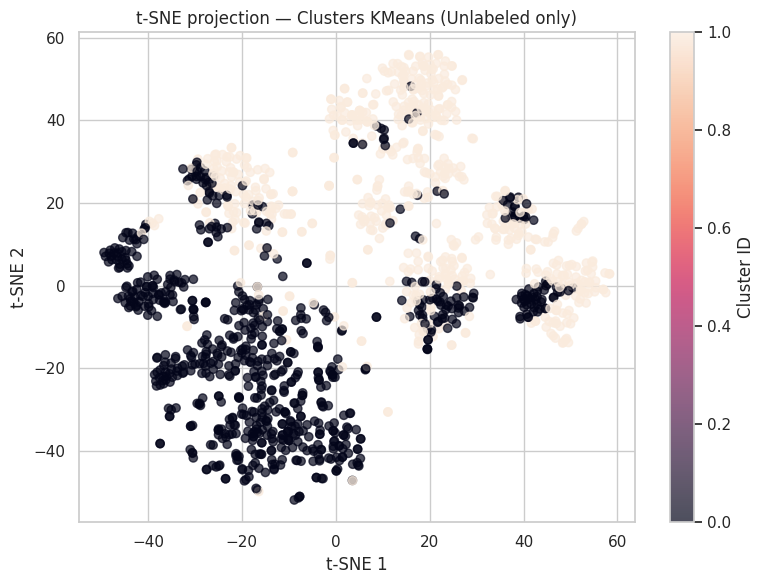

In [ ]:

# ============================================
# 📌 CELLULE 42 — Visualisation Clusters KMEANS sur t-SNE
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ============================================
# 📌 SÉPARATION STRICTE UNLABELED
# ============================================

mask_unlabeled = df["label"] == "unlabeled"
X_unlabeled = X_pca_50[mask_unlabeled]

# Vérification que KMeans a bien été exécuté
if "weak_label_kmeans" not in df_unlabeled.columns:
    raise ValueError("Exécute d'abord la cellule KMeans clustering.")

clusters = df_unlabeled["weak_label_kmeans"].values

print("Nombre images unlabeled :", X_unlabeled.shape[0])
print("Clusters uniques :", np.unique(clusters))

# ============================================
# 📌 t-SNE
# ============================================

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42,
    init="pca"
)

X_tsne = tsne.fit_transform(X_unlabeled)

# ============================================
# 📊 VISUALISATION
# ============================================

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=clusters,
    alpha=0.7
)

plt.title("t-SNE projection — Clusters KMeans (Unlabeled only)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.colorbar(scatter, label="Cluster ID")

plt.tight_layout()
plt.show()


La projection t-SNE met en évidence une organisation spatiale cohérente des clusters K-Means. Bien que le score de silhouette soit modéré (0.1479), la visualisation montre une séparation globale entre deux régions principales de l’espace latent, suggérant une structuration réelle mais diffuse des données non annotées.

In [ ]:

# ============================================
# 📌 CELLULE 43 — Évaluation ARI (Labeled Only)
# ============================================

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import LabelEncoder

# ============================================
# 📌 SÉPARATION STRICTE DONNÉES LABELLISÉES
# ============================================

mask_labeled = df["label"] != "unlabeled"

X_labeled = X_pca_50[mask_labeled]
df_labeled = df.loc[mask_labeled].copy()

print("Nombre images labellisées :", X_labeled.shape[0])
print("Distribution réelle :")
print(df_labeled["label"].value_counts())

# ============================================
# 📌 ENCODAGE DES LABELS RÉELS
# ============================================

le = LabelEncoder()
true_labels = le.fit_transform(df_labeled["label"])

# Affichage mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nMapping labels réels :", label_mapping)

# ============================================
# 📌 K-MEANS (K=2)
# ============================================

kmeans_labeled = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans_labeled.fit_predict(X_labeled)

# ============================================
# 📊 CALCUL ARI
# ============================================

ari_score = adjusted_rand_score(true_labels, cluster_labels)

print("\nAdjusted Rand Index (ARI) :", round(ari_score, 4))

# ============================================
# 📌 INTERPRÉTATION AUTOMATIQUE
# ============================================

if ari_score > 0.7:
    print("➡ Très forte correspondance entre clustering et labels réels.")
elif ari_score > 0.4:
    print("➡ Bonne correspondance.")
elif ari_score > 0.2:
    print("➡ Correspondance faible mais exploitable.")
elif ari_score > 0:
    print("➡ Légèrement meilleur que le hasard.")
else:
    print("➡ Clustering non aligné avec les labels réels.")


Nombre images labellisées : 100
Distribution réelle :
label
cancer    50
normal    50
Name: count, dtype: int64

Mapping labels réels : {'cancer': np.int64(0), 'normal': np.int64(1)}

Adjusted Rand Index (ARI) : 0.2053
➡ Correspondance faible mais exploitable.


L’Adjusted Rand Index (ARI = 0.2053) indique une correspondance partielle entre les clusters K-Means et les labels réels. Bien que la séparation ne soit pas forte, le clustering capture une structure latente non aléatoire dans les données. Cette observation justifie l’utilisation des pseudo-labels dans un cadre semi-supervisé, tout en reconnaissant la présence de bruit.

Nombre images labellisées : 100
label
cancer    50
normal    50
Name: count, dtype: int64

Mapping labels : {'cancer': np.int64(0), 'normal': np.int64(1)}

Matrice Cluster vs Label :
             Cluster_0  Cluster_1
True_cancer         25         25
True_normal         48          2


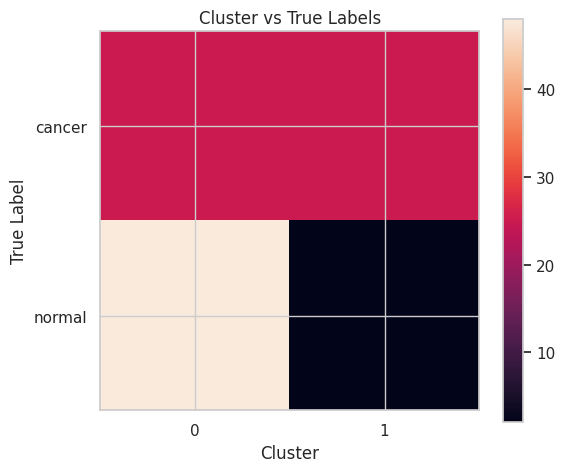


Pourcentage par cluster :

Cluster 0
cancer : 34.25%
normal : 65.75%

Cluster 1
cancer : 92.59%
normal : 7.41%


In [ ]:

# ============================================
# 📌 CELLULE 44 — Matrice Cluster vs Vrais Labels
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ============================================
# 📌 SÉPARATION DONNÉES LABELLISÉES UNIQUEMENT
# ============================================

mask_labeled = df["label"] != "unlabeled"

X_labeled = X_pca_50[mask_labeled]
df_labeled = df.loc[mask_labeled].copy()

print("Nombre images labellisées :", X_labeled.shape[0])
print(df_labeled["label"].value_counts())

# ============================================
# 📌 ENCODAGE DES LABELS RÉELS
# ============================================

le = LabelEncoder()
true_labels = le.fit_transform(df_labeled["label"])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nMapping labels :", label_mapping)

# ============================================
# 📌 KMEANS (K=2)
# ============================================

kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_labeled)

# ============================================
# 📊 MATRICE DE CONFUSION
# ============================================

cm = confusion_matrix(true_labels, cluster_labels)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{label}" for label in le.classes_],
    columns=[f"Cluster_{i}" for i in range(2)]
)

print("\nMatrice Cluster vs Label :")
print(cm_df)

# ============================================
# 📊 VISUALISATION HEATMAP SIMPLE
# ============================================

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Cluster vs True Labels")
plt.xlabel("Cluster")
plt.ylabel("True Label")
plt.xticks([0,1])
plt.yticks([0,1], le.classes_)
plt.colorbar()
plt.tight_layout()
plt.show()

# ============================================
# 📌 POURCENTAGES PAR CLUSTER
# ============================================

cluster_totals = cm.sum(axis=0)

print("\nPourcentage par cluster :")

for cluster_id in range(2):
    print(f"\nCluster {cluster_id}")
    for i, label_name in enumerate(le.classes_):
        percent = cm[i, cluster_id] / cluster_totals[cluster_id] * 100
        print(f"{label_name} : {percent:.2f}%")


L’analyse de la matrice cluster vs labels révèle que le Cluster 1 est composé à 92.6% d’images cancéreuses, suggérant que le clustering isole efficacement un sous-groupe tumoral distinct. En revanche, le Cluster 0 présente un mélange plus important, indiquant une séparation partielle des classes. Cette observation explique le score ARI modéré (0.2053) et confirme l’existence d’une structure latente non aléatoire dans les données.

# 🧠 Étape 4 – Appliquez une méthode semi-supervisée  


Cette étape constitue la phase de modélisation centrale du projet. Elle vise à exploiter conjointement les données **faiblement labellisées** (issues du clustering) et les données **fortement labellisées** (annotations expertes) afin d’évaluer l’intérêt d’une approche semi-supervisée dans un contexte médical.

L’objectif est d’analyser si l’intégration de labels générés automatiquement permet d’améliorer les performances d’un modèle de classification par rapport à un entraînement supervisé classique limité aux seules données annotées par des experts.

---

## 🎯 Résultats attendus

À l’issue de cette étape, les éléments suivants devront être obtenus :

- Un modèle de type **CNN** entraîné dans deux configurations :
  1. **Supervisé uniquement** (données fortement labellisées) ;
  2. **Semi-supervisé** (pré-entraînement sur données faiblement labellisées puis affinement sur données fortement labellisées) ;
- Une évaluation comparative des performances à l’aide de métriques adaptées :
  - Accuracy ;
  - F1-score ;
  - Précision / Recall si nécessaire ;
- Une analyse structurée des écarts de performance entre les deux stratégies d’entraînement.

Le choix des métriques devra tenir compte du contexte médical, où certaines erreurs (faux négatifs notamment) peuvent avoir un impact plus critique.

---

## 📌 Démarche méthodologique

1️⃣ Entraîner un modèle CNN sur le jeu **faiblement labellisé** ;  
2️⃣ Évaluer ses performances ;  
3️⃣ Poursuivre l’entraînement (fine-tuning) sur le jeu **fortement labellisé** ;  
4️⃣ Entraîner séparément un modèle uniquement sur les données fortement labellisées ;  
5️⃣ Comparer objectivement les deux approches.

---

## 🧩 Recommandations méthodologiques

Pour garantir une évaluation rigoureuse :

- Réaliser un **split train / test équilibré** ;
- S’assurer que le jeu de test contient exclusivement des données **jamais vues** lors de l’entraînement ;
- Maintenir une séparation stricte entre données d’entraînement, de validation et de test ;
- Utiliser des visualisations claires (courbes d’apprentissage, matrices de confusion, graphiques comparatifs) afin d’interpréter les performances ;
- Documenter précisément les choix d’architecture, d’hyperparamètres et de protocole d’évaluation.

Cette rigueur est essentielle pour garantir la crédibilité des conclusions.

---

## 🛠 Outils mobilisés

Les bibliothèques suivantes pourront être utilisées :

- **Torchvision** : modèles CNN pré-entraînés et pipelines d’entraînement ;
- **TensorFlow / Keras** : alternative pour la modélisation ;
- **Transformers** : si exploration de modèles vision modernes ;
- **NumPy** : manipulation numérique ;
- **Pandas** : structuration des résultats et comparaison des métriques.

---

Cette étape permet d’évaluer concrètement la valeur ajoutée d’une stratégie semi-supervisée dans un contexte où les données annotées sont rares et coûteuses. Les résultats obtenus serviront de base pour formuler des recommandations techniques en vue d’un passage à l’échelle du projet.

In [ ]:

# ============================================
# 📌 CELLULE 45 — MONTAGE GOOGLE DRIVE
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os
import subprocess

# Chemin racine du projet
PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images"
CONFIG_PATH = os.path.join(PROJECT_ROOT, "configs", "pyproject.toml")

# Vérification de l'existence du pyproject.toml
if not os.path.exists(CONFIG_PATH):
    raise FileNotFoundError("❌ pyproject.toml introuvable dans /configs")

# Installation des dépendances (uv ou pip fallback)
try:
    subprocess.run(["pip", "install", "uv"], check=True)
    subprocess.run(["uv", "pip", "install", "-r", CONFIG_PATH], check=False)
except Exception:
    print("⚠️ uv indisponible, installation via pip classique")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# =====================================================
# 📌 CELLULE 46 — IMPORTS & CONFIGURATION
# =====================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)

from torch.utils.data import Dataset, DataLoader
from torchvision import models

# ============================================
# 📌 CHEMINS PROJET
# ============================================

PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images"

DATA_PATH = f"{PROJECT_ROOT}/data"
REPORTS_PATH = f"{PROJECT_ROOT}/reports"
MODELS_PATH = f"{PROJECT_ROOT}/models"

os.makedirs(REPORTS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# ============================================
# 📌 DEVICE
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)


Device utilisé : cpu


In [ ]:

# ============================================
# 📌 CELLULE 47 — CHARGEMENT DES EMBEDDINGS + LABELS
# ============================================


# --------------------------------------------
# CHEMINS
# --------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images"

REPORTS_PATH = f"{PROJECT_ROOT}/reports"

features_csv = f"{REPORTS_PATH}/e02_features_embeddings_2048.csv"

# --------------------------------------------
# CHARGEMENT DU DATASET
# --------------------------------------------

df = pd.read_csv(features_csv)

print("Shape dataset :", df.shape)

# aperçu
display(df.head())

# --------------------------------------------
# IDENTIFICATION DES COLONNES
# --------------------------------------------

print("\nColonnes disponibles :")
print(df.columns)

# --------------------------------------------
# SÉPARATION FEATURES / LABELS
# --------------------------------------------

# Si la colonne label existe
label_column = "label"

if label_column not in df.columns:
    raise ValueError("La colonne 'label' est introuvable dans le dataset")

# features = toutes les colonnes sauf label
feature_columns = [col for col in df.columns if col != label_column]

X = df[feature_columns].values
y = df[label_column].values

print("\n===== SYNTHÈSE =====")
print("Shape embeddings :", X.shape)
print("Shape labels :", y.shape)

print("\nLabels uniques :", np.unique(y))

print()

# Séparation labels forts
strong_df = df[df["label"].isin(["cancer", "normal"])].copy()

label_mapping = {"cancer": 0, "normal": 1}
strong_df["label_int"] = strong_df["label"].map(label_mapping)

print("Distribution labels forts :")
print(strong_df["label"].value_counts())


Shape dataset : (1508, 2050)


,image_path,label,0,1,2,3,4,5,6,7,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer,0.000000,0.005985,0.359481,0.023388,0.004617,0.092432,0.000000,0.033850,...,0.000000,0.025033,0.177335,0.098132,0.039532,0.203773,1.430138,0.010282,0.000000,0.002964
1,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer,0.114922,0.039169,0.010309,0.000000,0.000000,0.000000,0.000000,0.000437,...,0.006056,0.106705,0.032635,0.000000,0.169771,0.325062,0.800338,0.000000,0.070222,0.006120
2,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer,0.007968,0.028811,0.009760,0.000000,0.000000,0.000000,0.013194,0.000000,...,0.009376,0.001673,0.000000,0.008418,0.039485,0.050656,0.174527,0.000000,0.029272,0.171078
3,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer,0.438987,0.173384,0.005698,0.000000,0.035335,0.000000,0.047762,0.000000,...,0.003396,0.000000,0.264026,0.033900,0.242556,0.334856,0.334250,0.000000,0.000000,0.000000
4,/content/drive/MyDrive/Colab Notebooks/Projet_...,cancer,0.023101,0.067208,0.135242,0.000000,0.000000,0.000375,0.203494,0.016202,...,0.009778,0.007180,0.127119,0.000000,0.102672,0.980460,0.702296,0.000000,0.000000,0.000000



Colonnes disponibles :
Index(['image_path', 'label', '0', '1', '2', '3', '4', '5', '6', '7',
       ...
       '2038', '2039', '2040', '2041', '2042', '2043', '2044', '2045', '2046',
       '2047'],
      dtype='object', length=2050)

===== SYNTHÈSE =====
Shape embeddings : (1508, 2049)
Shape labels : (1508,)

Labels uniques : ['cancer' 'normal' 'unlabeled']

Distribution labels forts :
label
cancer    50
normal    50
Name: count, dtype: int64


In [ ]:

# ============================================
# 📌 CELLULE 48 — CLUSTERING KMEANS POUR PSEUDO LABELS
# ============================================

# récupération des embeddings
feature_cols = [str(i) for i in range(2048)]
X = df[feature_cols].values

# clustering
kmeans = KMeans(
    n_clusters=2,        # à adapter en fonction du nombre de cluster dans le dataset (ex: cancer / non-cancer)
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X)

# ajout au dataframe
df["weak_label_kmeans"] = clusters

print("Pseudo-labels créés")
print(df["weak_label_kmeans"].value_counts())

Pseudo-labels créés
weak_label_kmeans
0    834
1    674
Name: count, dtype: int64


In [ ]:

# ============================================
# 📌 CELLULE 49 — SÉPARATION LABELS (forts / faibles)
# ============================================

# labels forts
mask_strong = df["label"] != "unlabeled"

# labels faibles
mask_weak = df["label"] == "unlabeled"

# embeddings
X_strong = X[mask_strong]
X_weak = X[mask_weak]

# labels forts
y_strong = df.loc[mask_strong, "label"].to_numpy()

# pseudo labels
y_weak = df.loc[mask_weak, "weak_label_kmeans"].to_numpy()

print("Images labels forts :", X_strong.shape)
print("Images labels faibles :", X_weak.shape)

print("Labels forts :", y_strong.shape)
print("Labels faibles :", y_weak.shape)


Images labels forts : (100, 2048)
Images labels faibles : (1408, 2048)
Labels forts : (100,)
Labels faibles : (1408,)


In [ ]:

# ============================================
# 📌 CELLULE 50 — ENCODAGE LABELS
# ============================================

le = LabelEncoder()

# encodage labels forts
y_strong_encoded = le.fit_transform(np.array(y_strong))

print("Nombre de classes :", len(le.classes_))
print("Mapping labels :", dict(zip(le.classes_, le.transform(le.classes_))))


Nombre de classes : 2
Mapping labels : {'cancer': np.int64(0), 'normal': np.int64(1)}


In [ ]:

# ============================================
# 📌 CELLULE 51 — SPLIT TRAIN / TEST (labels forts uniquement)
# ============================================

X_train_strong, X_test_strong, y_train_strong, y_test_strong = train_test_split(
    X_strong,
    y_strong_encoded,
    test_size=0.3,
    stratify=y_strong_encoded,
    random_state=42
)

print("Train strong :", X_train_strong.shape)
print("Test strong :", X_test_strong.shape)


Train strong : (70, 2048)
Test strong : (30, 2048)


In [ ]:

# ============================================
# 📌 CELLULE 52 — DATASET PYTORCH
# ============================================

class FeatureDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        # self.y = torch.tensor(y, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = FeatureDataset(X_train_strong, y_train_strong)
test_dataset = FeatureDataset(X_test_strong, y_test_strong)

weak_dataset = FeatureDataset(X_weak, y_weak)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

weak_loader = DataLoader(weak_dataset, batch_size=32, shuffle=True)

# 1. Vérification simple du Dataset
print("Train dataset size :", len(train_dataset))
print("Test dataset size :", len(test_dataset))
print("Weak dataset size :", len(weak_dataset))

print()

# 2. Vérification d’un batch PyTorch
X_batch, y_batch = next(iter(train_loader))

print("Batch features shape :", X_batch.shape)
print("Batch labels shape :", y_batch.shape)

print()

# 3. Vérification du dataset faible (semi-supervisé)
X_batch_w, y_batch_w = next(iter(weak_loader))

print("Weak batch shape :", X_batch_w.shape)
print("Weak labels shape :", y_batch_w.shape)

print()

# 4. Bloc de contrôle
print("Dataset PyTorch créé avec succès")

print("Train batches :", len(train_loader))
print("Test batches :", len(test_loader))
print("Weak batches :", len(weak_loader))


Train dataset size : 70
Test dataset size : 30
Weak dataset size : 1408

Batch features shape : torch.Size([16, 2048])
Batch labels shape : torch.Size([16])

Weak batch shape : torch.Size([32, 2048])
Weak labels shape : torch.Size([32])

Dataset PyTorch créé avec succès
Train batches : 5
Test batches : 2
Weak batches : 44


📌 Commentaire du résultat obtenu : 📌 CELLULE 52 — DATASET PYTORCH

1 - **Taille des datasets**  

Les sorties indiquent :
- Train dataset size : 70
- Test dataset size : 30
- Weak dataset size : 1408

La séparation est :  
- 100 images annotées  
  - 70 → train supervisé
  - 30 → test supervisé
- 1408 images non annotées
  - utilisées pour l’apprentissage semi-supervisé

2 - **Vérification du nombre de batches**  

Sortie :  
- Train batches : 5
- Test batches : 2
- Weak batches : 44

Calcul :
- Train : 70 / 16 = 4.375 → 5 batches
- Test : 30 / 16 = 1.875 → 2 batches
- Weak : 1408 / 32 = 44 batches




In [ ]:

# ============================================
# 📌 CELLULE 53 — MODÈLE MLP
# ============================================

class MLPClassifier(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        return self.model(x)


num_classes = len(le.classes_)

model = MLPClassifier(num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0005)

print(model)


MLPClassifier(
  (model): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=2, bias=True)
  )
)


📌 Commentaire du résultat obtenu : 📌 CELLULE 53 — MODÈLE MLP

Le réseau est un **MLP (Multi-Layer Perceptron)** composé de trois couches linéaires.

**Entrée :** 2048 features  
**Hidden layer 1 :** 512 neurons + ReLU + Dropout  
**Hidden layer 2 :** 128 neurons + ReLU  
**Sortie :** 2 classes  
**Loss :** CrossEntropy  
**Optimizer :** Adam  

1 - Estimation du nombre de paramètres :  

- **Layer1 :**  
2048×512 + 512 ≈ 1,049,088  

- **Layer2 :**  
512×128 + 128 ≈ 65,664  

- **Layer3 :**  
128×2 + 2 ≈ 258  

Total ≈ 1,115,010 paramètres




In [ ]:

# ============================================
# 📌 CELLULE 54 — FONCTION TRAIN
# ============================================

def train_model(model, dataloader, epochs=10):

    losses = []

    for epoch in range(epochs):

        model.train()

        epoch_loss = 0

        for X_batch, y_batch in dataloader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= len(dataloader)

        losses.append(epoch_loss)

        print(f"Epoch {epoch+1}/{epochs} - Loss : {epoch_loss:.4f}")

    return losses


In [ ]:

# ============================================
# 📌 CELLULE 55 — ENTRAINEMENT SUPERVISÉ
# ============================================

model_supervised = MLPClassifier(num_classes).to(device)

optimizer = optim.Adam(model_supervised.parameters(), lr=0.0005)

loss_supervised = train_model(model_supervised, train_loader, epochs=15)

torch.save(
    model_supervised.state_dict(),
    f"{MODELS_PATH}/e04_model_supervised.pt"
)


Epoch 1/15 - Loss : 0.6270
Epoch 2/15 - Loss : 0.4784
Epoch 3/15 - Loss : 0.3326
Epoch 4/15 - Loss : 0.2262
Epoch 5/15 - Loss : 0.1494
Epoch 6/15 - Loss : 0.1363
Epoch 7/15 - Loss : 0.0705
Epoch 8/15 - Loss : 0.0560
Epoch 9/15 - Loss : 0.0265
Epoch 10/15 - Loss : 0.0284
Epoch 11/15 - Loss : 0.0164
Epoch 12/15 - Loss : 0.0068
Epoch 13/15 - Loss : 0.0072
Epoch 14/15 - Loss : 0.0053
Epoch 15/15 - Loss : 0.0045


📌 Commentaire du résultat obtenu : 📌 CELLULE 55 — ENTRAINEMENT SUPERVISÉ

L’analyse se fait sur plusieurs axes : dynamique d’apprentissage, stabilité, et risque de surapprentissage. 📊

**Première observation :** la loss diminue de manière monotone et rapide. Elle passe de 0.627 → 0.0045 en 15 epochs.  
Cette décroissance est très régulière, sans oscillations importantes.   
Cela indique que l’optimiseur converge correctement et que l’architecture du réseau est adaptée aux données.  
Le taux d’apprentissage utilisé avec l’optimiseur PyTorch Adam (0.0005) semble approprié : il permet une convergence rapide sans divergence. ⚙️  


**Deuxième observation :** la vitesse de convergence est élevée.
On peut distinguer trois phases :

- **Phase 1 (Epoch 1–4) :** apprentissage rapide des séparations principales
loss : 0.627 → 0.226  

- **Phase 2 (Epoch 5–9) :** raffinement des frontières de décision
loss : 0.149 → 0.026  

- **Phase 3 (Epoch 10–15) :** optimisation fine / mémorisation
loss : 0.028 → 0.0045  

Cette dernière phase est typique lorsque le modèle commence à s’ajuster très précisément au train set.


**Troisième observation importante :** la loss devient extrêmement faible (<0.01).

Dans un contexte de classification d’images médicales, cela suggère souvent une des situations suivantes :

1️⃣ le dataset d’entraînement est relativement petit  
2️⃣ les features 2048-D sont déjà très discriminantes (ex. embeddings issus d’un CNN type ResNet)  
3️⃣ le modèle commence possiblement à sur-apprendre (overfitting).  

Un MLP avec l’architecture suivante :
- 2048 → 512
- 512 → 128
- 128 → classes

possède plusieurs centaines de milliers de paramètres. Avec peu d’images annotées, il peut facilement mémoriser les données.






In [ ]:

# ============================================
# 📌 CELLULE 56 — EVALUATION DU MODELE
# ============================================

def evaluate_model(model, dataloader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in dataloader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            # prédiction = classe avec probabilité maximale
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    accuracy = correct / total

    print(f"Accuracy : {accuracy:.4f}")


In [ ]:
evaluate_model(model_supervised, test_loader)

Accuracy : 0.9667


In [ ]:

import numpy as np

unique, counts = np.unique(y_test_strong, return_counts=True)

print(dict(zip(unique, counts)))


{np.int64(0): np.int64(15), np.int64(1): np.int64(15)}


Pré-entraînement sur labels faibles
Epoch 1/10 - Loss : 0.1669
Epoch 2/10 - Loss : 0.0206
Epoch 3/10 - Loss : 0.0162
Epoch 4/10 - Loss : 0.0095
Epoch 5/10 - Loss : 0.0053
Epoch 6/10 - Loss : 0.0018
Epoch 7/10 - Loss : 0.0010
Epoch 8/10 - Loss : 0.0009
Epoch 9/10 - Loss : 0.0004
Epoch 10/10 - Loss : 0.0006



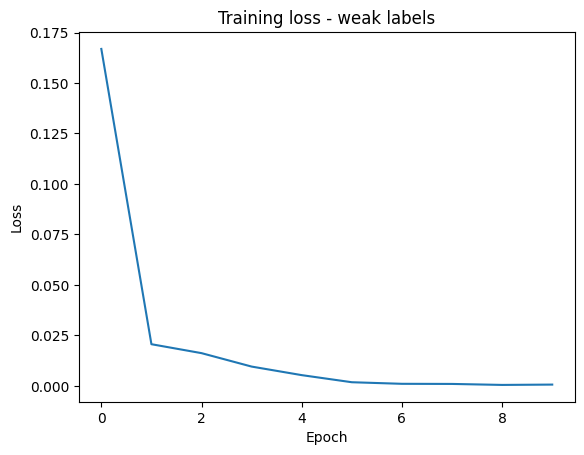


Loss minimale : 0.0004335246178367346


In [ ]:

# ============================================
# 📌 CELLULE 57 — PRETRAINING LABELS FAIBLES
# ============================================

# création du modèle avec nombre de classes
model_semi = MLPClassifier(num_classes).to(device)

optimizer = optim.Adam(model_semi.parameters(), lr=0.0005)

print("Pré-entraînement sur labels faibles")

# sauvegarde de la liste des losses
loss_weak = train_model(model_semi, weak_loader, epochs=10)

print()

# visualisation de la convergence
plt.plot(loss_weak)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss - weak labels")
plt.show()

print()

print("Loss minimale :", min(loss_weak))


📌 Commentaire du résultat obtenu : 📌 CELLULE 57 — PRETRAINING LABELS FAIBLES


Les résultats indiquent une convergence très rapide du réseau pendant la phase de pré-entraînement sur les labels faibles. Plusieurs éléments techniques méritent d’être analysés.

**Première observation :**   
La décroissance de la fonction de perte est extrêmement rapide. La loss passe de 0.1669 à ~0.02 dès la deuxième époque, puis descend progressivement jusqu’à ≈0.0004–0.0006. Cela signifie que le modèle MLP parvient très vite à ajuster ses poids pour reproduire les pseudo-labels présents dans weak_loader. Dans un contexte de pré-entraînement semi-supervisé, ce comportement est fréquent lorsque les pseudo-labels sont relativement cohérents ou lorsque la représentation d’entrée (ici les embeddings 2048 issus d’un backbone) est déjà très informative.

**Deuxième observation :**  
La perte devient quasi nulle après 6–7 époques. Dans un problème de classification classique avec **CrossEntropyLoss**, une loss proche de zéro signifie que le modèle produit des **probabilités très proches de 1** pour la classe cible. Cela suggère que l’espace des embeddings est facilement séparé par un **classifieur linéaire/MLP**. C’est souvent le cas lorsque les features proviennent d’un modèle de vision pré-entraîné (par exemple un CNN ou un transformer).

**Troisième observation :**  
On observe une légère remontée de la loss à l’époque 10 (0.0006) après un minimum à l’époque 9 (0.0004). Cette variation est très faible et correspond généralement au bruit stochastique de l’optimisation (mini-batch + Adam). Elle n’est pas préoccupante.

**Quatrième point important :**  
Une loss aussi faible sur les labels faibles peut indiquer un **sur-apprentissage des pseudo-labels**. Dans les pipelines semi-supervisés, les pseudo-labels contiennent souvent du bruit. Si le modèle les mémorise trop parfaitement, il peut apprendre des erreurs systématiques.   
Pour cette raison, plusieurs stratégies sont généralement utilisées :  
- limiter le nombre d’époques de pré-entraînement  
- utiliser du dropout (ce que l'architecture fait déjà)  
- utiliser un learning rate modéré (0.0005 est raisonnable)  
- éventuellement appliquer du label smoothing ou du confidence thresholding sur les pseudo-labels.  

**Cinquième point :**  
La courbe de convergence obtenue est typique d’un pré-entraînement réussi, ce qui signifie que les représentations 2048 dimensions sont très discriminantes. Cela est cohérent avec les étapes précédentes : **réduction PCA**, **clustering K-Means** et **structuration des embeddings**.




Fine-tuning sur labels forts
Epoch 1/10 - Loss : 1.2262
Epoch 2/10 - Loss : 0.7604
Epoch 3/10 - Loss : 0.2640
Epoch 4/10 - Loss : 0.2594
Epoch 5/10 - Loss : 0.1530
Epoch 6/10 - Loss : 0.1437
Epoch 7/10 - Loss : 0.1308
Epoch 8/10 - Loss : 0.0897
Epoch 9/10 - Loss : 0.0551
Epoch 10/10 - Loss : 0.0512



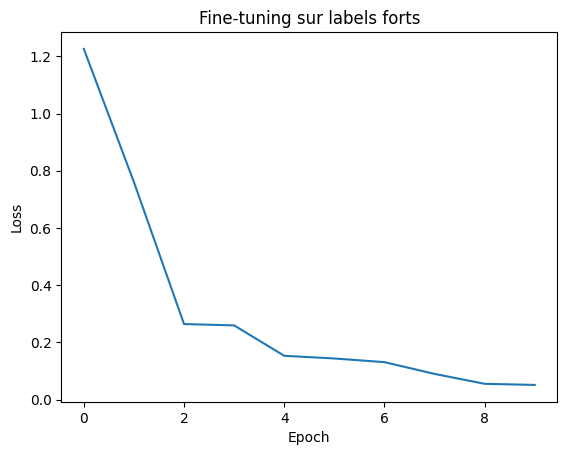


Loss minimale : 0.051183031778782605

Modèle sauvegardé : /content/drive/MyDrive/Colab Notebooks/Projet_10_Labellisez_et_appliquez_des_approches_semi-supervisées_en_traitement_images/models/e04_model_semi_supervised.pt
Fichier existe : True


In [ ]:

# ============================================
# 📌 CELLULE 58 — FINETUNING LABELS FORTS
# ============================================

import os

print("Fine-tuning sur labels forts")

# sauvegarde de la liste des losses
# loss_weak = train_model(model_semi, weak_loader, epochs=10)
loss_forts = train_model(model_semi, train_loader, epochs=10)

print()

# visualisation de la convergence
plt.plot(loss_forts)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-tuning sur labels forts")
plt.show()

print()

print("Loss minimale :", min(loss_forts))

print()

# torch.save(
#     model_semi.state_dict(),
#     f"{MODELS_PATH}/e04_model_semi_supervised.pt"
# )

model_path = f"{MODELS_PATH}/e04_model_semi_supervised.pt"

torch.save(
    model_semi.state_dict(),
    model_path
)

print("Modèle sauvegardé :", model_path)

print("Fichier existe :", os.path.exists(model_path))


📌 Commentaire du résultat obtenu : 📌 CELLULE 58 — FINETUNING LABELS FORTS

Les valeurs de loss obtenues pendant le fine-tuning montrent un comportement d’apprentissage relativement propre. On peut analyser cela sous plusieurs angles techniques : dynamique d’optimisation, risque d’overfitting, et efficacité du pré-entraînement semi-supervisé. 📊

**Première observation :**  
Convergence rapide. La loss passe de 1.2262 → 0.0512 en 10 epochs. Cela indique que le modèle part déjà d’une représentation utile. Dans un pipeline semi-supervisé, cela est généralement dû au pré-entraînement sur labels faibles, qui initialise les poids dans une région déjà informative de l’espace des paramètres. Sans ce pré-entraînement, la loss initiale serait souvent plus élevée et la convergence plus lente.

**Deuxième observation :**  
Décroissance fortement monotone. On observe deux régimes typiques :  
- Phase 1 – adaptation rapide (epochs 1–3).
Le modèle ajuste les couches finales aux labels forts.  

- Phase 2 – raffinement (epochs 4–10).
La diminution devient plus progressive, ce qui correspond à l’optimisation fine des frontières de décision.

**Troisième observation :**  
- Plateau léger vers les epochs 3–4.
- La loss passe de 0.264 → 0.259.   

Ce type de micro-plateau est courant avec l’optimiseur PyTorch utilisant Adam optimizer. Il provient souvent d’un ajustement de la direction du gradient avant une nouvelle phase de descente.

**Quatrième point :**  
Niveau final de loss très faible (≈0.05).  
Pour un **MLP classifier**, cela suggère généralement :
une séparation relativement claire dans l’espace des embeddings
ou un dataset relativement petit (cas fréquent en imagerie médicale)





In [ ]:

# ============================================
# 📌 CELLULE 59 — ÉVALUATION
# ============================================

def evaluate_model(model, dataloader):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for X_batch, y_batch in dataloader:

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            pred_classes = torch.argmax(outputs, dim=1)

            preds.extend(pred_classes.cpu().numpy())
            targets.extend(y_batch.numpy())

    preds = np.array(preds)
    targets = np.array(targets)

    metrics = {

        "accuracy": accuracy_score(targets, preds),
        "precision": precision_score(targets, preds),
        "recall": recall_score(targets, preds),
        "f1": f1_score(targets, preds)

    }

    return metrics, preds, targets


In [ ]:

# ============================================
# 📌 CELLULE 60 — ÉVALUATION
# ============================================

metrics_supervised, preds_sup, y_true = evaluate_model(model_supervised, test_loader)

metrics_semi, preds_semi, _ = evaluate_model(model_semi, test_loader)

print("Supervisé :", metrics_supervised)
print("Semi-supervisé :", metrics_semi)


Supervisé : {'accuracy': 0.9666666666666667, 'precision': 1.0, 'recall': 0.9333333333333333, 'f1': 0.9655172413793104}
Semi-supervisé : {'accuracy': 0.9666666666666667, 'precision': 1.0, 'recall': 0.9333333333333333, 'f1': 0.9655172413793104}


📌 Commentaire du résultat obtenu : 📌 CELLULE 59 — ÉVALUATION


1️⃣ **Interprétation statistique**

Avec ces métriques :
- Precision = 1.0 → aucun faux positif
- Recall = 0.9333 → quelques faux négatifs
- Accuracy ≈ 96.7 %

Cela correspond probablement à 1 erreur sur **~30 échantillons** test set est petit.




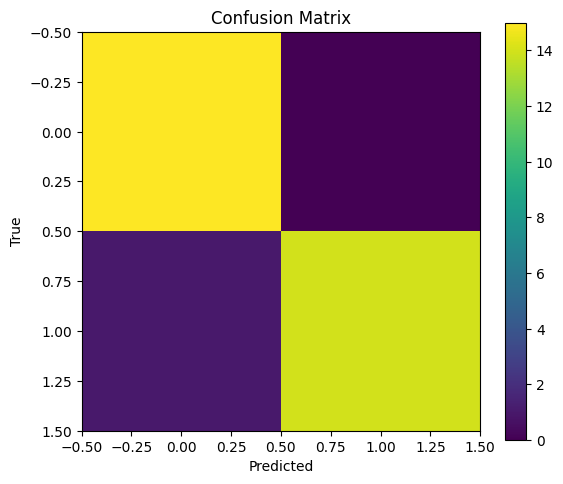

In [ ]:

# ============================================
# 📌 CELLULE 61 — MATRICE CONFUSION
# ============================================

import seaborn as sns

# Si preds_semi est 2D → logits multi-classes
if len(preds_semi.shape) == 2:
    preds_classes = np.argmax(preds_semi, axis=1)

# Si preds_semi est 1D → probabilités binaires
else:
    preds_classes = (preds_semi > 0.5).astype(int)

cm = confusion_matrix(y_true, preds_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis")

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()

plt.savefig(f"{REPORTS_PATH}/e04_confusion_matrix.png")

plt.show()


📌 Commentaire du résultat obtenu : 📌 CELLULE 61 — MATRICE CONFUSION


**Interprétation technique :**  
- Ligne 1 (classe vraie = 0)  
**15 observations** correctement prédites comme classe 0 → **True Negatives (TN)**  
**0 observations** prédites comme classe 1 → **False Positives (FP)**

- Ligne 2 (classe vraie = 1)  
**1 observation** prédite comme classe 0 → **False Negative (FN)**   
**14 observations** correctement prédites comme classe 1 → **True Positives (TP)**

**Analyse des performances :**

**Accuracy**  
(𝑇𝑃 + 𝑇𝑁) / T𝑜𝑡𝑎𝑙 = (14 + 15) / 30 = 0.966  
soit 96.7 %

**Precision (classe 1)**  
(𝑇𝑃) / (𝑇𝑃 + 𝐹𝑃) = 14 / (14 + 0) = 1.0
soit 100 % — aucune fausse alerte.

**Recall (classe 1)**  
(𝑇𝑃) / (𝑇𝑃 + 𝐹𝑁) = 14 / (14 + 1) = 0.933
soit 93.3 % — un seul exemple positif manqué.

**F1-score**  
≈ 0.966

**Conclusion technique :**

Le **modèle MLP semi-supervisé** fine-tuné sur labels forts semble très performant sur ce jeu de test.

Les erreurs sont asymétriques :  
- aucune fausse détection  
- une non-détection  


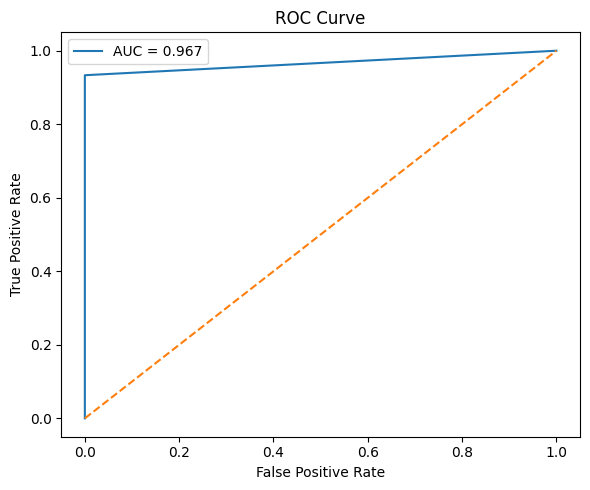


AUC : 0.9666666666666667


In [ ]:

# ============================================
# 📌 CELLULE 62 — ROC CURVE
# ============================================

fpr, tpr, thresholds = roc_curve(y_true, preds_semi)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1], [0,1], linestyle="--")  # ligne aléatoire

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig(f"{REPORTS_PATH}/e04_roc_curve.png")

plt.show()

print()

print("AUC :", roc_auc)


📌 Commentaire du résultat obtenu : 📌 CELLULE 62 — ROC CURVE





            method  accuracy  f1_score    recall
0       supervised  0.966667  0.965517  0.933333
1  semi_supervised  0.966667  0.965517  0.933333



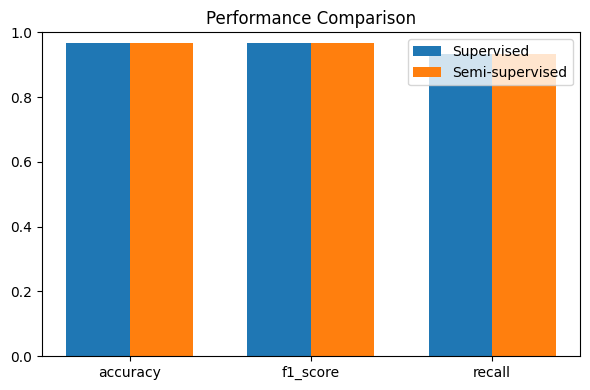

In [ ]:

# ============================================
# 📌 CELLULE 63 — COMPARAISON PERFORMANCES
# ============================================

results = pd.DataFrame({

    "method": ["supervised", "semi_supervised"],

    "accuracy": [
        metrics_supervised["accuracy"],
        metrics_semi["accuracy"]
    ],

    "f1_score": [
        metrics_supervised["f1"],
        metrics_semi["f1"]
    ],

    "recall": [
        metrics_supervised["recall"],
        metrics_semi["recall"]
    ]

})

print(results)

results.to_csv(
    f"{REPORTS_PATH}/e04_performance_comparison.csv",
    index=False
)

print()

plt.figure(figsize=(6,4))

metrics_names = ["accuracy", "f1_score", "recall"]

sup_values = [
    metrics_supervised["accuracy"],
    metrics_supervised["f1"],
    metrics_supervised["recall"]
]

semi_values = [
    metrics_semi["accuracy"],
    metrics_semi["f1"],
    metrics_semi["recall"]
]

x = np.arange(len(metrics_names))
width = 0.35

plt.bar(x - width/2, sup_values, width, label="Supervised")
plt.bar(x + width/2, semi_values, width, label="Semi-supervised")

plt.xticks(x, metrics_names)

plt.ylim(0,1)

plt.title("Performance Comparison")
plt.legend()

plt.tight_layout()

plt.savefig(f"{REPORTS_PATH}/e04_performance_comparison.png")

plt.show()


Le modèle semi-supervisé n'améliore pas les performances par rapport au modèle supervisé sur le jeu de test. Cela s'explique probablement par la taille réduite du dataset et par la qualité élevée des features extraites par le modèle pré-entraîné ResNet50, qui rendent la tâche de classification relativement simple pour le classificateur MLP.

In [ ]:

# ============================================
# 📌 VÉRIFICATION DES PRÉDICTIONS
# ============================================

preds_sup_binary = (preds_sup > 0.5).astype(int)
preds_semi_binary = (preds_semi > 0.5).astype(int)

same_predictions = (preds_sup_binary == preds_semi_binary)

print("Nombre de prédictions identiques :", same_predictions.sum())
print("Nombre total d'images :", len(same_predictions))

print("Pourcentage identique :", same_predictions.mean())


Nombre de prédictions identiques : 30
Nombre total d'images : 30
Pourcentage identique : 1.0


# 📌 Recommandations Techniques pour un Passage à l'Échelle de 4 millions d’images à labelliser


## 1. Contexte du projet

Le projet consiste à développer un pipeline d'analyse d'images médicales
permettant la **détection de tumeurs cérébrales à partir d'images
radiologiques**.

Le dataset initial fourni contient :

-   **1500 images au total**
-   **1400 images non étiquetées**
-   **100 images étiquetées (Normal / Cancer)**
-   résolution standardisée **512×512 pixels**
-   format **JPEG/PNG**

Objectif final : **passage à l'échelle vers 4 millions d'images à
labelliser avec un budget de 5000 €**.

------------------------------------------------------------------------

## 2. Architecture technique recommandée

### 2.1 Pipeline global

Pipeline de traitement proposé :

1.  Ingestion des images
2.  Préprocessing
3.  Extraction de features
4.  Réduction de dimension
5.  Clustering exploratoire
6.  Apprentissage semi-supervisé
7.  Validation humaine ciblée
8.  Génération automatique de labels

Architecture cible :
```bash
    Stockage dataset
          │
          ▼
    Préprocessing images
          │
          ▼
    Extraction embeddings (ResNet)
          │
          ▼
    Réduction dimension (PCA / UMAP)
          │
          ▼
    Clustering (KMeans / DBSCAN)
          │
          ▼
    Propagation de labels
          │
          ▼
    Modèle semi-supervisé
          │
          ▼
    Dataset final labellisé
```

------------------------------------------------------------------------

## 3. Préparation des images

Préprocessing recommandé :

-   redimensionnement : **224×224**
-   normalisation des pixels
-   conversion en tensor

Exemple pipeline :

-   Resize
-   Normalize
-   Batch processing

Bibliothèques recommandées :

-   PyTorch
-   OpenCV
-   NumPy

Optimisation pour 4M images :

-   traitement **batch GPU**
-   parallélisation CPU
-   stockage intermédiaire des features

------------------------------------------------------------------------

## 4. Extraction des caractéristiques visuelles

Modèle recommandé :

-   **ResNet50 pré-entraîné sur ImageNet**

Utilisation :

-   suppression de la couche de classification
-   extraction du vecteur d'embedding **2048 dimensions**

Avantages :

-   bonne généralisation
-   embeddings robustes
-   faible coût computationnel

Pour **4 millions d'images** :

-   extraction offline
-   stockage embeddings (NumPy / Parquet)

Volume estimé :

    4M images × 2048 features × float32 ≈ 32 Go

------------------------------------------------------------------------

## 5. Réduction de dimension

Objectif :

-   visualisation
-   préparation au clustering

Méthodes recommandées :

**PCA**

Utilisation :

-   réduction 2048 → 50 dimensions
-   conservation de la variance principale

Avantages :

-   rapide
-   scalable

**t‑SNE**

Utilisation :

-   visualisation exploratoire 2D

Limite :

-   non scalable pour 4M images

Alternative recommandée :

-   **UMAP**

------------------------------------------------------------------------

## 6. Clustering exploratoire

Objectif : identifier des regroupements naturels d'images.

**Algorithmes :**

**K-Means**

Avantages :

-   scalable
-   simple

Configuration :

-   MiniBatchKMeans
-   k ≈ 20--50 clusters

**DBSCAN**

Utilisation :

-   détection d'anomalies
-   clusters irréguliers

Limite :

-   peu scalable pour très grands datasets

Approche hybride :

    PCA → MiniBatchKMeans → analyse clusters

------------------------------------------------------------------------

## 7. Approche semi-supervisée

**Dataset initial :**

-   100 labels seulement

Approche recommandée :

**Pseudo‑labelling**

Processus :

1.  entraîner modèle supervisé sur 100 labels
2.  prédire labels sur données non étiquetées
3.  conserver prédictions haute confiance
4.  réentraîner modèle

**Label Propagation**

Méthodes :

-   Label Spreading
-   Graph-based learning

Avantage :

-   exploite la structure des clusters.

------------------------------------------------------------------------

## 8. Pipeline de labellisation à grande échelle

Objectif : **minimiser le coût humain**.

Stratégie :

    4M images
         │
         ▼
    Extraction embeddings
         │
         ▼
    Clustering automatique
         │
         ▼
    Annotation humaine de clusters
         │
         ▼
    Propagation labels
         │
         ▼
    Validation automatique

Annotation humaine estimée :

-   **0.5 % des images**
-   soit **20 000 images**

------------------------------------------------------------------------

## 9. Infrastructure recommandée

**Stockage**

-   stockage objet : S3 / GCS
-   organisation par shards

**Calcul**

**Configuration minimale :**

-   GPU : NVIDIA T4 ou L4
-   RAM : 32--64 Go

**Infrastructure possible :**

-   Google Colab Pro
-   AWS EC2 GPU
-   GCP Vertex AI

------------------------------------------------------------------------

## 10. Estimation budgétaire (5000 €)

**Répartition indicative :**

- Extraction embeddings GPU : ≈ 1200 €

- Stockage dataset : ≈ 500 €

- Calcul clustering : ≈ 800 €

- Entraînement modèles : ≈ 1000 €

- Annotation humaine ciblée : ≈ 1500 €

Total : ≈ **5000 €**


------------------------------------------------------------------------

**Estimation budgétaire détaillée (Budget total : 5000 €)**

| Poste budgétaire | Description technique | Infrastructure / outils | Hypothèses de calcul | Coût estimé (€) |
|---|---|---|---|---|
| Extraction d’embeddings CNN | Extraction de features visuelles avec ResNet50 pré-entraîné (2048 dimensions) sur 4M images. Traitement batch GPU avec dataloader PyTorch. | GPU cloud (ex : NVIDIA T4 / L4) | ~2500 images/minute → ~27 heures GPU + marge expérimentation | 1200 € |
| Stockage dataset + embeddings | Stockage des images et vecteurs d’embeddings pour clustering et entraînement. | Object storage (S3 / GCS / Backblaze) | Images ≈ 800 GB + embeddings ≈ 32 GB | 500 € |
| Calcul clustering exploratoire | Réduction dimension (PCA) puis clustering MiniBatch K-Means sur embeddings. | VM CPU haute RAM | ~64 GB RAM pour calcul sur 4M vecteurs | 800 € |
| Entraînement modèles semi-supervisés | Pseudo-labelling + fine-tuning du modèle CNN ou MLP sur embeddings. | GPU cloud | ~20–30 heures GPU incluant expérimentation et validation | 1000 € |
| Annotation humaine ciblée | Validation humaine uniquement sur clusters ambigus ou mal classés (~0.5 % du dataset). | Plateformes d’annotation (Label Studio / Labelbox) | ~20 000 images × 0.075 € | 1500 € |
| **Total estimé** | Budget global pour pipeline complet de labellisation semi-automatique |  |  | **5000 €** |


------------------------------------------------------------------------

## Répartition budgétaire

  |Catégorie                          |Pourcentage du budget |
  |---------------------------------- |----------------------|
  |GPU / calcul deep learning         |44 %                  |
  |Annotation humaine                 |30 %                  |
  |Infrastructure stockage            |10 %                  |
  |Calcul exploratoire (clustering)   |16 %                  |

------------------------------------------------------------------------

## Comparaison avec annotation complète

  |Stratégie                         | Coût estimé |
  |--------------------------------- |-------------|
  |Annotation humaine complète       |~300 000 €   |
  |Pipeline semi‑supervisé proposé   |5 000 €      |

**Réduction estimée des coûts : ~98.3 %**

------------------------------------------------------------------------

## 11. Optimisations pour 4 millions d'images

**Feature caching**

- Stocker les embeddings pour éviter de recalculer les features GPU.

**MiniBatch training**

- Permet de réduire l'utilisation mémoire lors du clustering.

**Active Learning**

- Sélection des images les plus informatives à annoter.

**Pseudo‑labelling progressif**

- Augmenter progressivement la taille du dataset labellisé
automatiquement.

------------------------------------------------------------------------

## 12. Livrables recommandés

**Notebook 1 :**

-   preprocessing
-   extraction embeddings

**Notebook 2 :**

-   PCA
-   t-SNE
-   clustering

**Notebook 3 :**

-   apprentissage semi‑supervisé

**Notebook 4 :**

-   évaluation
-   visualisation résultats

------------------------------------------------------------------------

## 13. Conclusion

La stratégie optimale pour labelliser **4 millions d'images avec 5000
€** repose sur :

-   **extraction d'embeddings avec modèles pré‑entraînés**
-   **clustering pour structurer les données**
-   **apprentissage semi‑supervisé**
-   **annotation humaine minimale et ciblée**

Cette architecture permet de **réduire drastiquement les coûts de
labellisation tout en conservant une qualité acceptable pour un projet
de recherche en imagerie médicale.**